# Week 4

# DTU Data Exploration and Analysis

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [3]:
FEEDBACK_PATH = "data/raw/dtu/feedback"
SERIES_PATH = "data/raw/dtu/timeseries"


## Loading timeseries and feedback files

In [4]:
files = [p.name for p in Path(FEEDBACK_PATH).iterdir() if p.is_file()]
files = [filename for filename in files if filename.endswith(".csv") and "Room" in filename]

df_dict = {} 

for filename in files:
    room_name = filename.split(".")[0]
    feedback_path = Path(FEEDBACK_PATH) / filename
    series_path = Path(SERIES_PATH) / filename

    feedback_df = pd.read_csv(feedback_path)
    series_df = pd.read_csv(series_path)

    df_dict[room_name] = {
        "feedback": feedback_df,
        "series": series_df
    }

print(f"Loaded data for {len(df_dict)} rooms.")
for room_name, data in df_dict.items():
    print(f"Room: {room_name}")
    print(f"Feedback shape: {data['feedback'].shape}")
    print(f"Series shape: {data['series'].shape}")
    print(f"CO2 Nan values of Timeseries: {data['series']['co2'].isna().sum()}") 
    print()

Loaded data for 11 rooms.
Room: Room 009
Feedback shape: (29, 3)
Series shape: (41424, 9)
CO2 Nan values of Timeseries: 27076

Room: Room 019
Feedback shape: (44, 3)
Series shape: (43069, 12)
CO2 Nan values of Timeseries: 28729

Room: Room 054
Feedback shape: (12, 3)
Series shape: (71449, 9)
CO2 Nan values of Timeseries: 43450

Room: Room 001
Feedback shape: (1, 3)
Series shape: (23875, 5)
CO2 Nan values of Timeseries: 9583

Room: Room 015
Feedback shape: (52, 3)
Series shape: (24115, 5)
CO2 Nan values of Timeseries: 9774

Room: Room 016
Feedback shape: (14, 3)
Series shape: (28746, 9)
CO2 Nan values of Timeseries: 14411

Room: Room 007
Feedback shape: (17, 3)
Series shape: (41717, 9)
CO2 Nan values of Timeseries: 27379

Room: Room 012
Feedback shape: (16, 3)
Series shape: (41760, 9)
CO2 Nan values of Timeseries: 27413

Room: Room 004
Feedback shape: (4, 3)
Series shape: (37658, 9)
CO2 Nan values of Timeseries: 23387

Room: Room 010
Feedback shape: (12, 3)
Series shape: (30721, 8)
CO2 

| Room | Feedback shape | Series shape | CO2 NaN values |
|------|----------------|--------------|-----------------|
| Room 009 | (29, 3) | (41424, 9) | 27076 |
| Room 019 | (44, 3) | (43069, 12) | 28729 |
| Room 054 | (12, 3) | (71449, 9) | 43450 |
| Room 001 | (1, 3) | (23875, 5) | 9583 |
| Room 015 | (52, 3) | (24115, 5) | 9774 |
| Room 016 | (14, 3) | (28746, 9) | 14411 |
| Room 007 | (17, 3) | (41717, 9) | 27379 |
| Room 012 | (16, 3) | (41760, 9) | 27413 |
| Room 004 | (4, 3) | (37658, 9) | 23387 |
| Room 010 | (12, 3) | (30721, 8) | 16418 |
| Room 039 | (3, 3) | (13797, 4) | 0 |

In [5]:
from collections import Counter

series_col_counts = Counter()
feedback_col_counts = Counter()
n_dfs = len(df_dict)

for room_name, data in df_dict.items():
    series_cols = data["series"].columns
    feedback_cols = data["feedback"].columns

    series_col_counts.update(set(series_cols))
    feedback_col_counts.update(set(feedback_cols))

for col, count in series_col_counts.items():
    print(f"Series column: {col} appears in {count} dataframes")

for col, count in feedback_col_counts.items():
    print(f"Feedback column: {col} appears in {count} dataframes")


Series column: trv_temperature appears in 7 dataframes
Series column: closed appears in 8 dataframes
Series column: motor_range appears in 7 dataframes
Series column: motor_position appears in 7 dataframes
Series column: target_temperature appears in 7 dataframes
Series column: co2 appears in 11 dataframes
Series column: temperature appears in 11 dataframes
Series column: datetime appears in 11 dataframes
Series column: humidity appears in 11 dataframes
Series column: motor_range_x appears in 1 dataframes
Series column: trv_temperature_x appears in 1 dataframes
Series column: target_temperature_y appears in 1 dataframes
Series column: motor_position_y appears in 1 dataframes
Series column: target_temperature_x appears in 1 dataframes
Series column: motor_range_y appears in 1 dataframes
Series column: trv_temperature_y appears in 1 dataframes
Series column: motor_position_x appears in 1 dataframes
Feedback column: datetime appears in 11 dataframes
Feedback column: userId appears in 11 d

**Series columns**

| Column | Dataframes |
|--------|------------|
| humidity | 11 |
| datetime | 11 |
| temperature | 11 |
| co2 | 11 |
| closed | 8 |
| motor_range | 7 |
| target_temperature | 7 |
| trv_temperature | 7 |
| motor_position | 7 |
| motor_range_x | 1 |
| target_temperature_y | 1 |
| trv_temperature_y | 1 |
| trv_temperature_x | 1 |
| target_temperature_x | 1 |
| motor_position_y | 1 |
| motor_position_x | 1 |
| motor_range_y | 1 |

**Feedback columns**

| Column | Dataframes |
|--------|------------|
| datetime | 11 |
| userId | 11 |
| value | 11 |

The data varies a lot and some rooms have more data than others. The feedback data is very sparse and the series data has a lot of missing values. 

We know try to look at the summary statistics of the CO2 data to see if we can find any patterns.

## Summary statistics of Waiting time in the data

In [6]:
df_series = {}

idx_max_waiting_time_dict = {}

for room_name, data in df_dict.items():
    series_df = data['series']
    #We drop the NaN values in the 'co2' column to clean the data.
    #.copy() so the datetime assignment below writes to its own frame
    #instead of a slice (avoids the SettingWithCopyWarning).
    series_df = series_df.dropna(subset=['co2']).copy()
    series_df['datetime'] = pd.to_datetime(series_df['datetime'])
    df_series[room_name] = series_df

    # Waiting time = gap in seconds between consecutive readings
    waiting_time = series_df['datetime'].diff().dt.total_seconds()

    # Top 3 longest waiting times (index labels match series_df, so .loc works)
    top3 = waiting_time.nlargest(3)
    idx_top3 = top3.index.tolist()
    dates_top3 = series_df.loc[idx_top3, "datetime"].tolist()
    values_top3 = top3.tolist()

    idx_max_waiting_time_dict[room_name] = list(zip(dates_top3, values_top3, idx_top3))

    #print(f"Room: {room_name}")
    #print("Top 3 waiting times:")
    #for date, value, idx in idx_max_waiting_time_dict[room_name]:
    #    print(f"  {date} -> {value:.0f} seconds (index {idx})")
    print(waiting_time.describe())
    print()

count    14347.000000
mean       605.494319
std         78.694830
min         35.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       9066.000000
Name: datetime, dtype: float64

count    14339.000000
mean       605.837576
std         52.339568
min         36.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       4853.000000
Name: datetime, dtype: float64

count    27998.000000
mean       310.282163
std         45.543140
min          8.000000
25%        302.000000
50%        306.000000
75%        314.000000
max       4966.000000
Name: datetime, dtype: float64

count    14291.000000
mean       607.847526
std         69.890028
min         17.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       4835.000000
Name: datetime, dtype: float64

count    14340.000000
mean       605.780335
std         65.157939
min          8.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       6631

| Room | count | mean | std | min | 25% | 50% | 75% | max |
|------|-------|------|-----|-----|-----|-----|-----|-----|
| Room 009 | 14347 | 605.494 | 78.695 | 35 | 602 | 603 | 606 | 9066 |
| Room 019 | 14339 | 605.838 | 52.340 | 36 | 602 | 603 | 606 | 4853 |
| Room 054 | 27998 | 310.282 | 45.543 | 8 | 302 | 306 | 314 | 4966 |
| Room 001 | 14291 | 607.848 | 69.890 | 17 | 602 | 603 | 606 | 4835 |
| Room 015 | 14340 | 605.780 | 65.158 | 8 | 602 | 603 | 606 | 6631 |
| Room 016 | 14334 | 606.022 | 62.030 | 34 | 602 | 603 | 606 | 5424 |
| Room 007 | 14337 | 605.905 | 62.931 | 34 | 602 | 603 | 606 | 5359 |
| Room 012 | 14346 | 605.548 | 63.867 | 33 | 602 | 603 | 606 | 6626 |
| Room 004 | 14270 | 608.756 | 69.720 | 33 | 602 | 604 | 607 | 4853 |
| Room 010 | 14302 | 607.425 | 74.133 | 17 | 602 | 604 | 607 | 7257 |
| Room 039 | 13796 | 629.653 | 155.051 | 20 | 602 | 603 | 608 | 5483 |

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


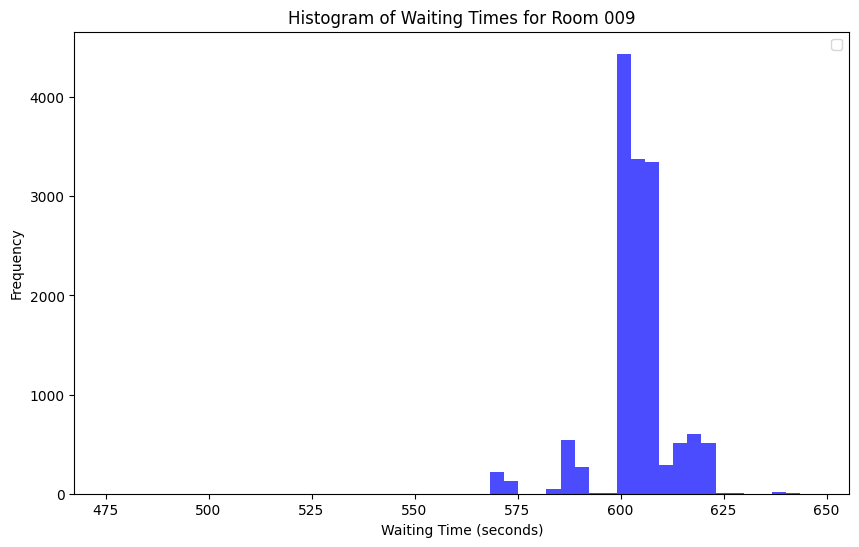

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


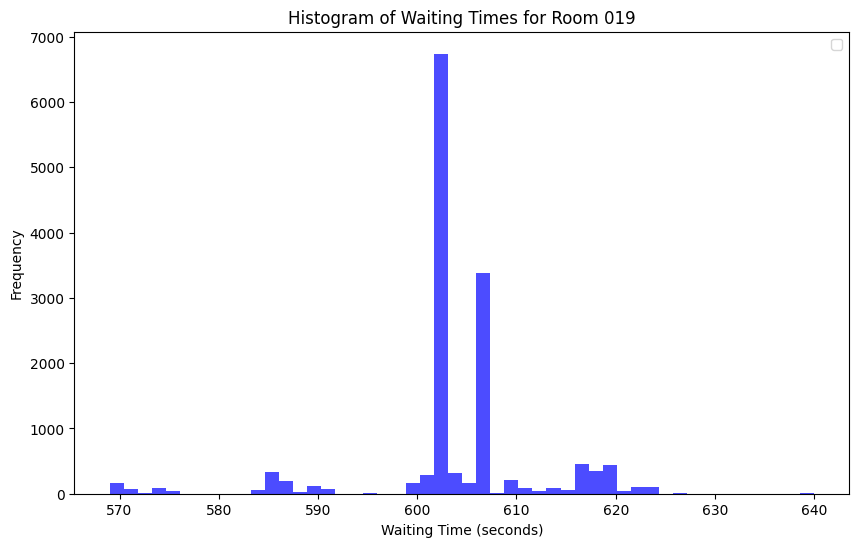

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


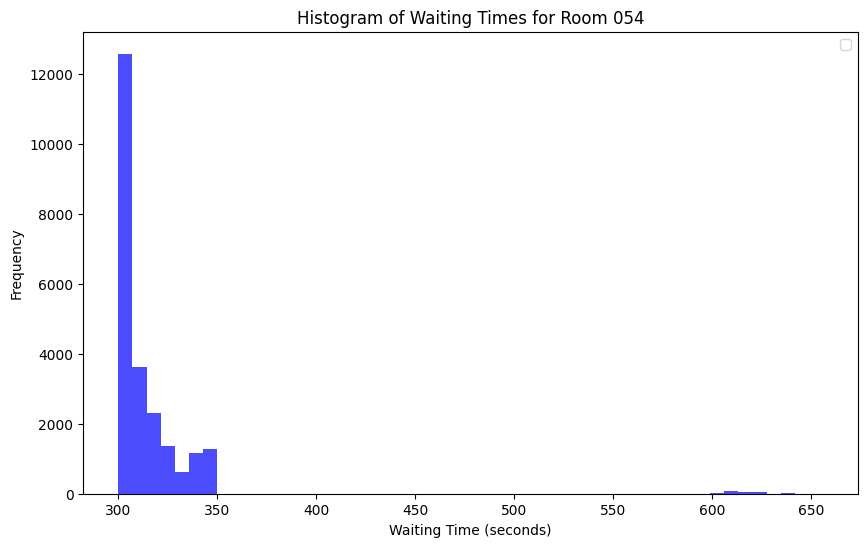

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


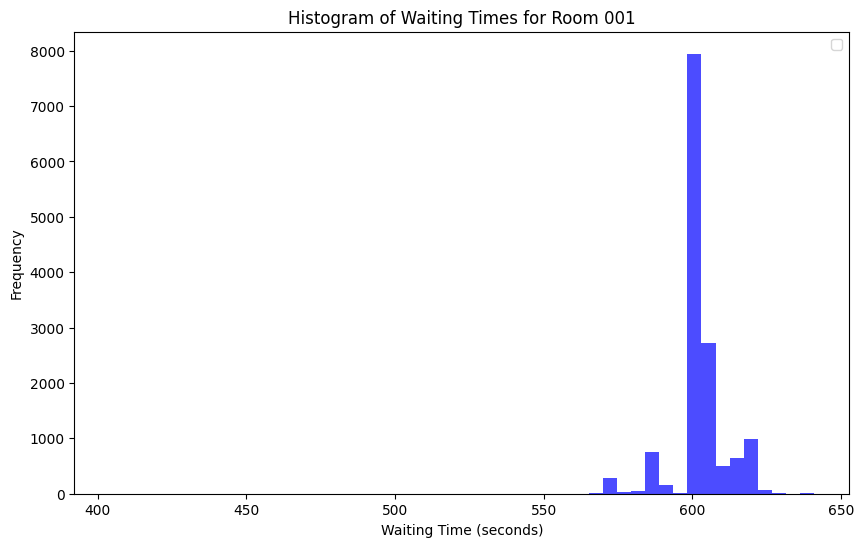

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


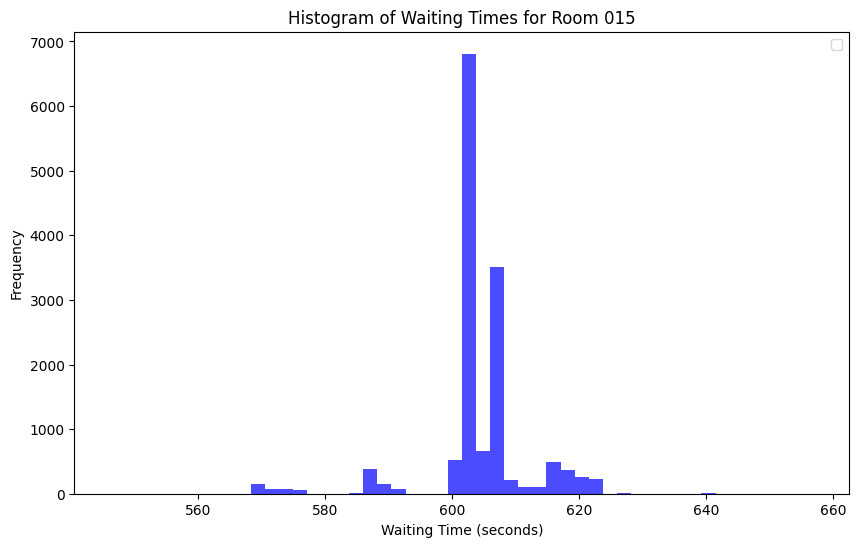

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


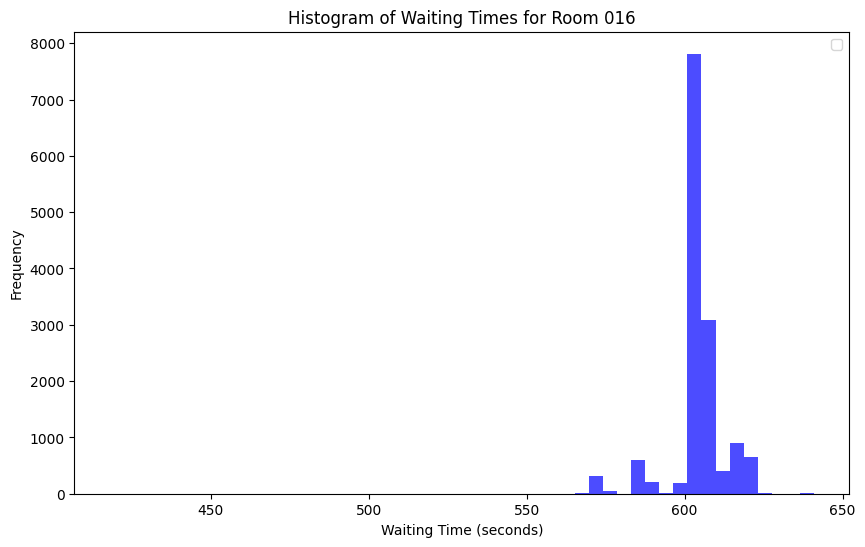

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


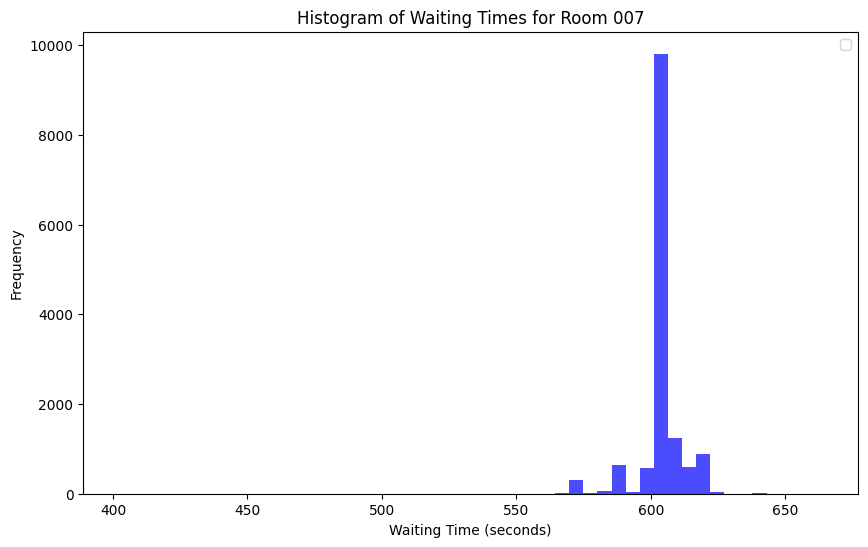

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


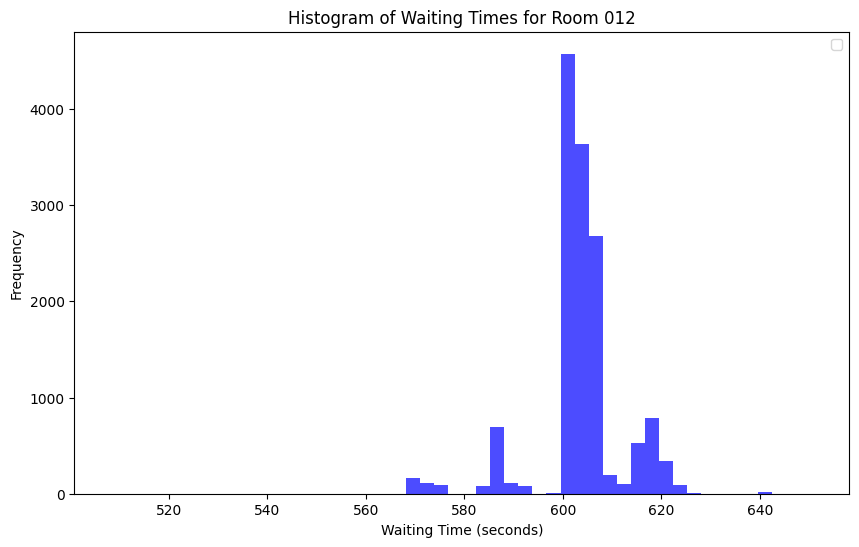

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


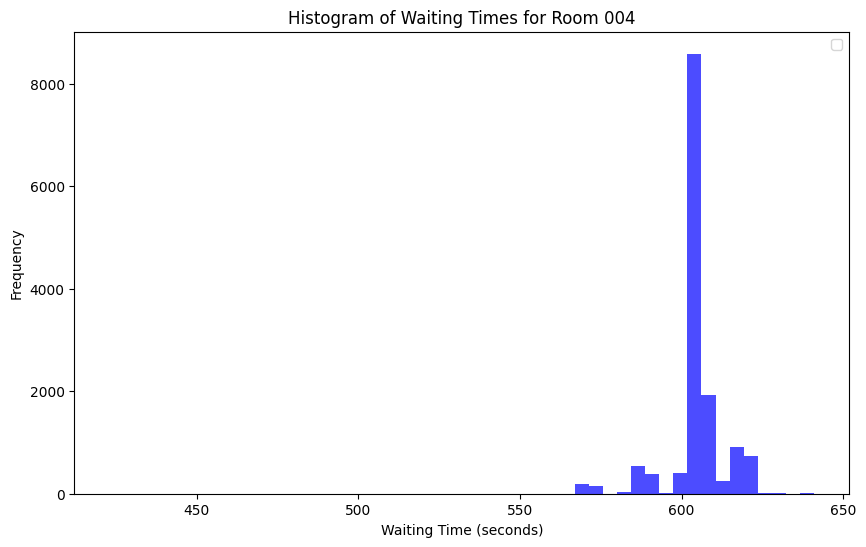

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


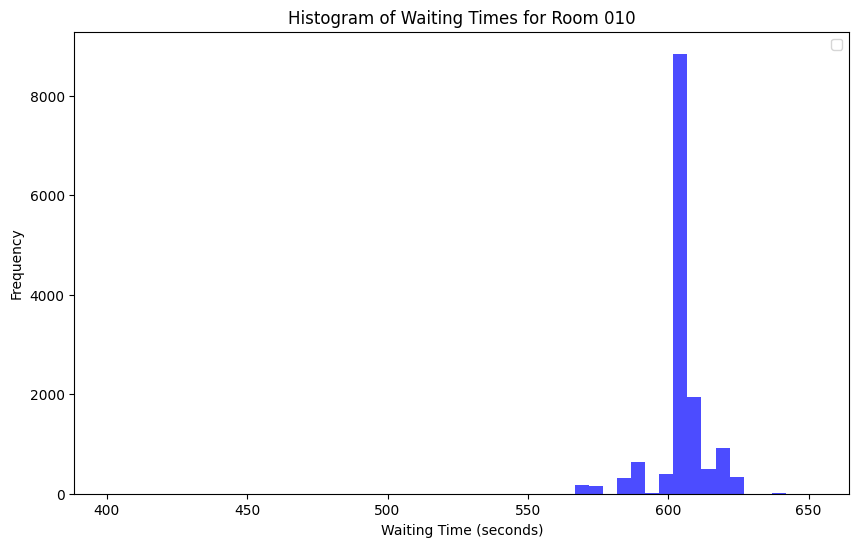

/var/folders/6x/jpylqzgs1yq2q_xtb9dv1lym0000gn/T/ipykernel_95668/737188173.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


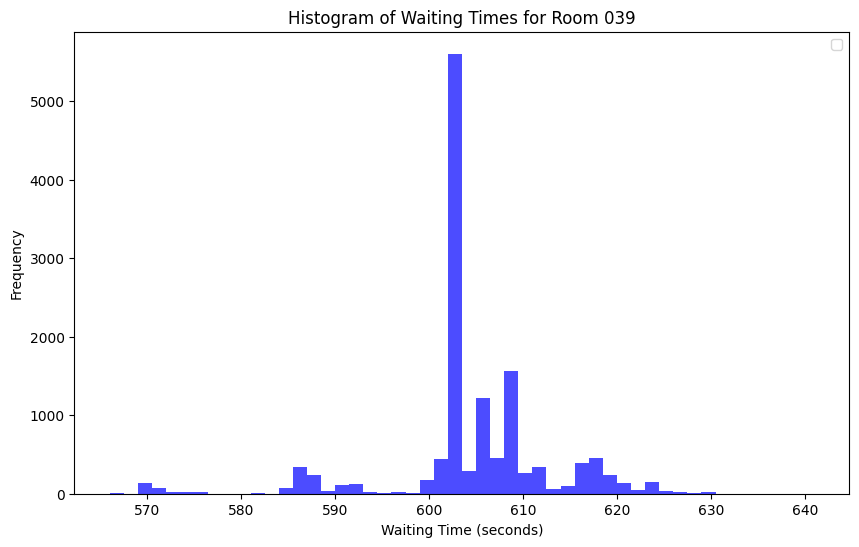

In [7]:
upper_threshold = 700 #seconds
lower_threshold = 300 #seconds
for room_name, series in df_series.items():
    waiting_time = series['datetime'].diff().dt.total_seconds() 
    #Find quantile of waiting times 
    

    #histogram of waiting times
    waiting_time_threshold = waiting_time[waiting_time <= upper_threshold]
    waiting_time_threshold = waiting_time_threshold[lower_threshold <= waiting_time]

    plt.figure(figsize=(10, 6))
    plt.hist(waiting_time_threshold.dropna(), bins=50, color='blue', alpha=0.7)
    plt.title(f"Histogram of Waiting Times for {room_name}")
    plt.xlabel("Waiting Time (seconds)")
    plt.ylabel("Frequency")
    #plt.axvline(threshold, color='red', linestyle='dashed', linewidth=1, label=f'Threshold: {threshold} seconds')
    plt.legend()
    plt.show()
    

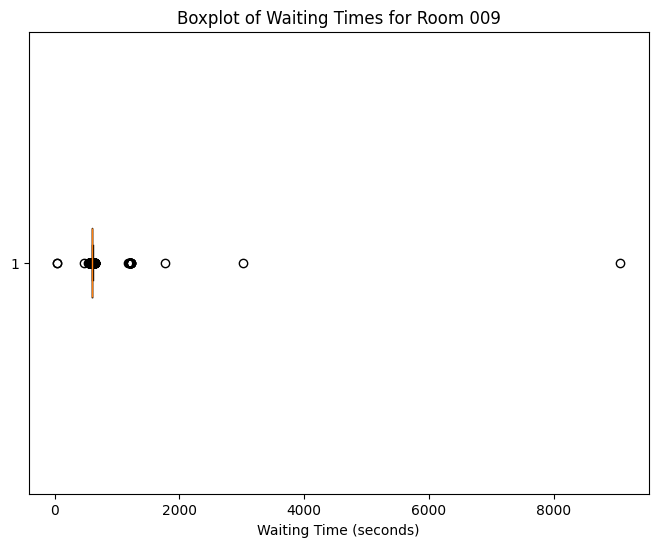

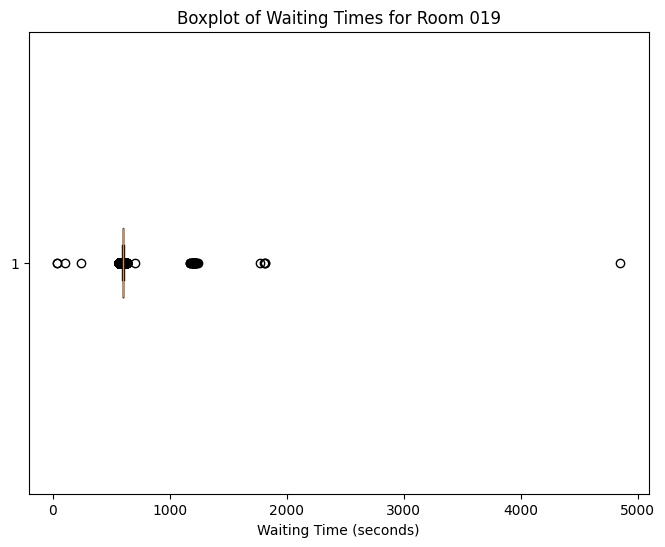

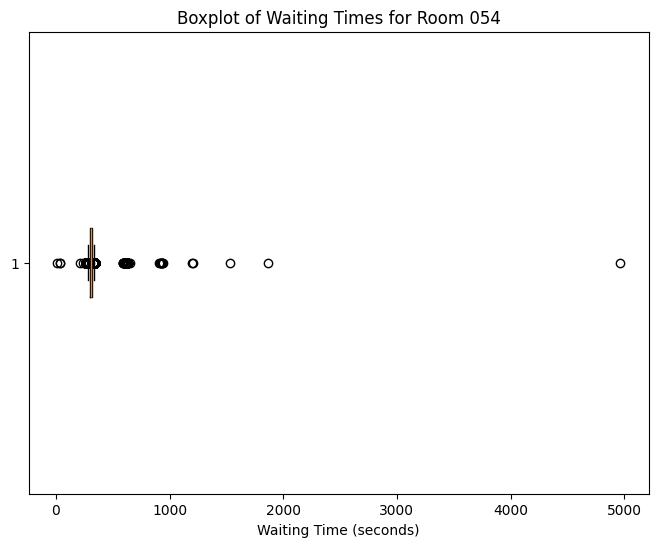

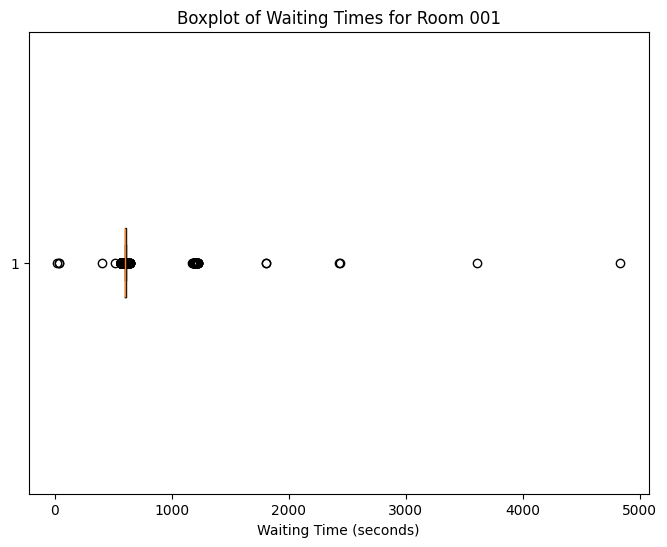

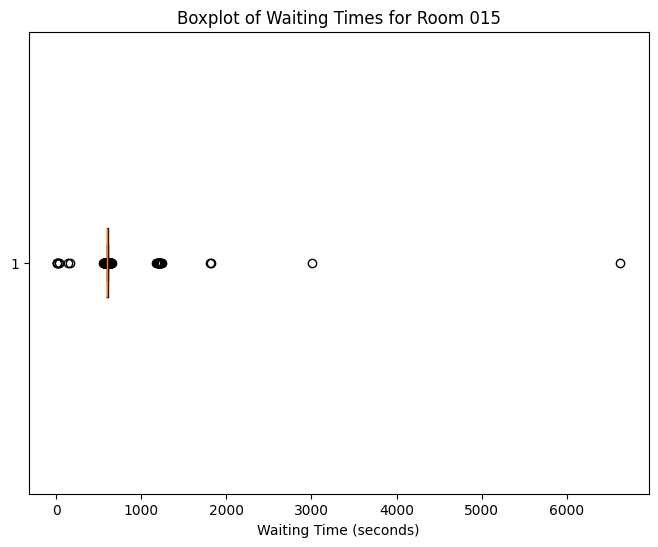

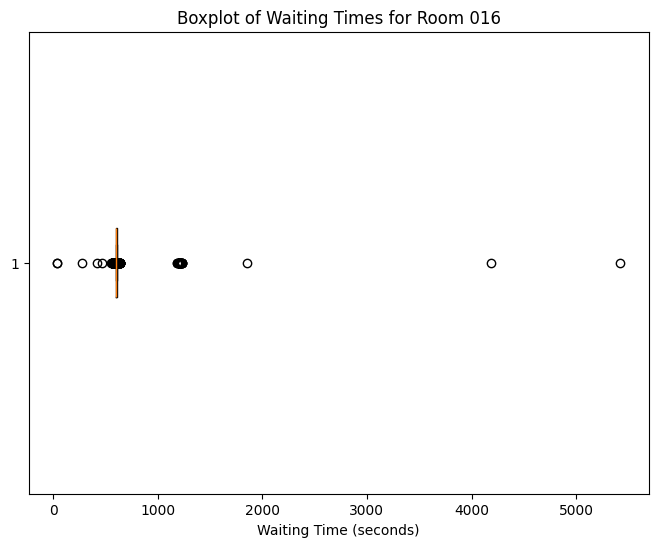

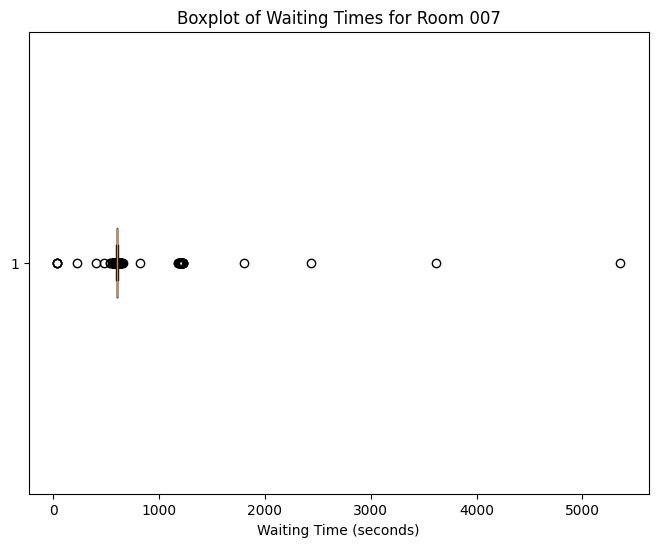

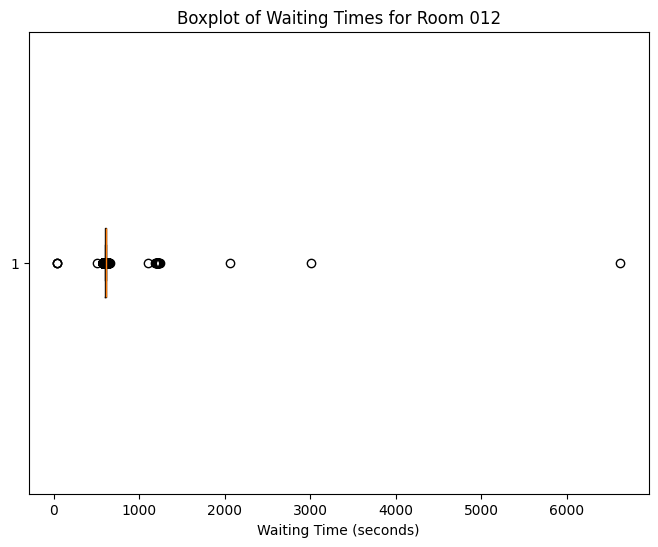

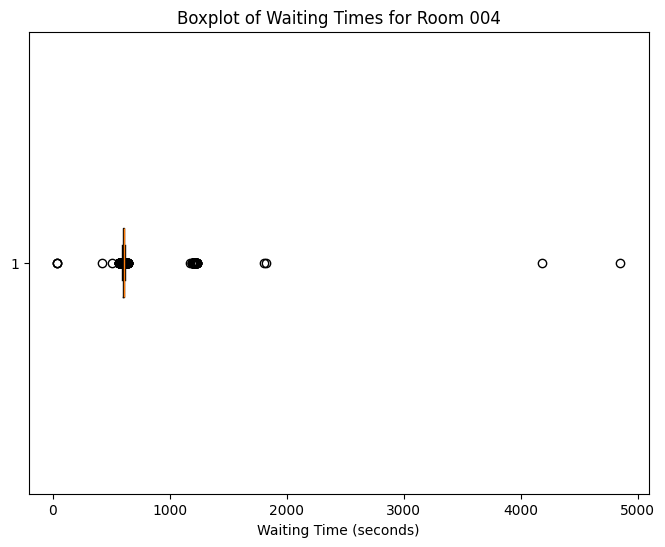

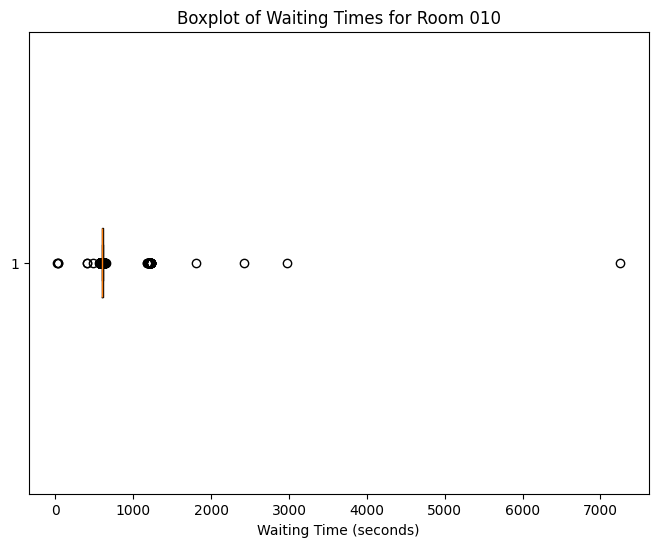

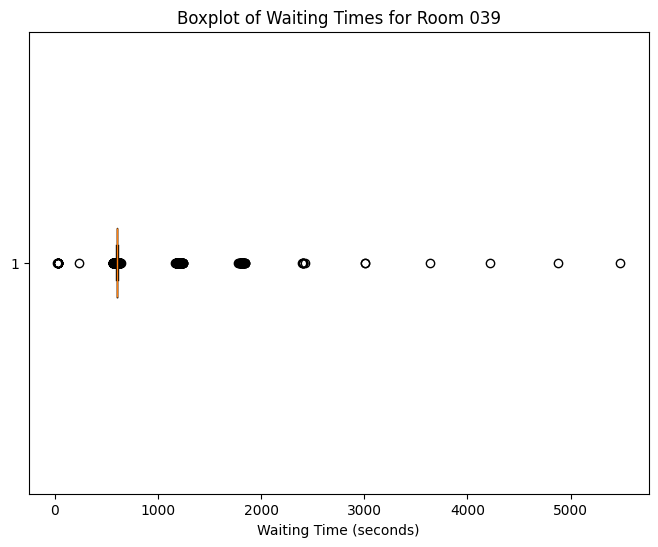

In [8]:
for room_name, series_df in df_series.items():
    # Printing boxplots of waiting times 
    waiting_time = series_df['datetime'].diff().dt.total_seconds()

    plt.figure(figsize=(8, 6))
    plt.boxplot(waiting_time.dropna(), vert=False)
    plt.title(f"Boxplot of Waiting Times for {room_name}")
    plt.xlabel("Waiting Time (seconds)")
    plt.show()

There is quite a few observations outside the 25-75% range, but the mean is very close to the median for all rooms. The waiting time is also very consistent across rooms with a mean of around 600 seconds.

This indicates that the waiting is NOT a geomtric or exponential distribution, but rather a normal distribution. Should we maybe consider a partial marov model for the waiting time?

## Summary Statistics of CO2 data

In [9]:
for room_name, series_df in df_series.items(): 
    # create summary statistics of CO2 values
    co2_values = series_df['co2'].dropna()
    summary_stats = co2_values.describe()
    print(f"Summary Statistics of CO2 Values for {room_name}:")
    print(summary_stats)

Summary Statistics of CO2 Values for Room 009:
count    14348.000000
mean       935.790424
std        551.321084
min        325.000000
25%        528.000000
50%        685.000000
75%       1219.000000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 019:
count    14340.000000
mean       887.373849
std        438.424399
min        355.000000
25%        531.000000
50%        727.000000
75%       1158.250000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 054:
count    27999.000000
mean      1048.117576
std        514.159062
min        276.000000
25%        642.000000
50%        919.000000
75%       1381.000000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 001:
count    14292.000000
mean       829.529177
std        517.716728
min        341.000000
25%        517.000000
50%        621.000000
75%        897.000000
max       5651.000000
Name: co2, dtype: float64
Summ

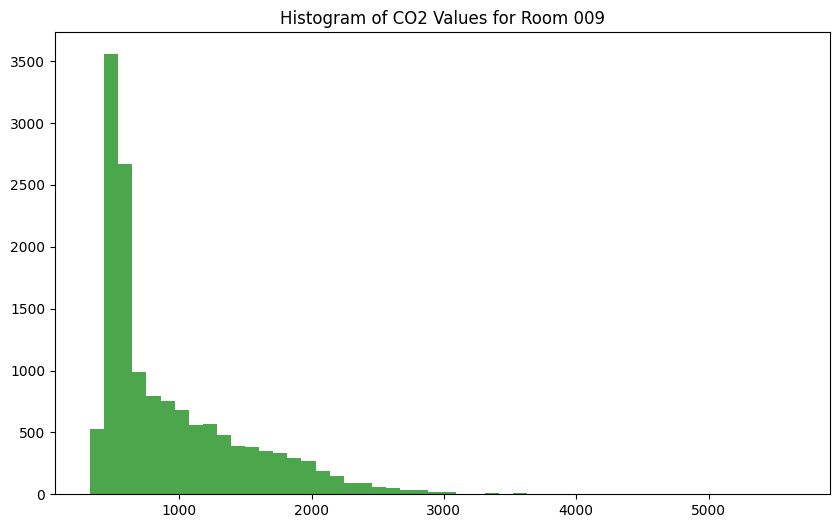

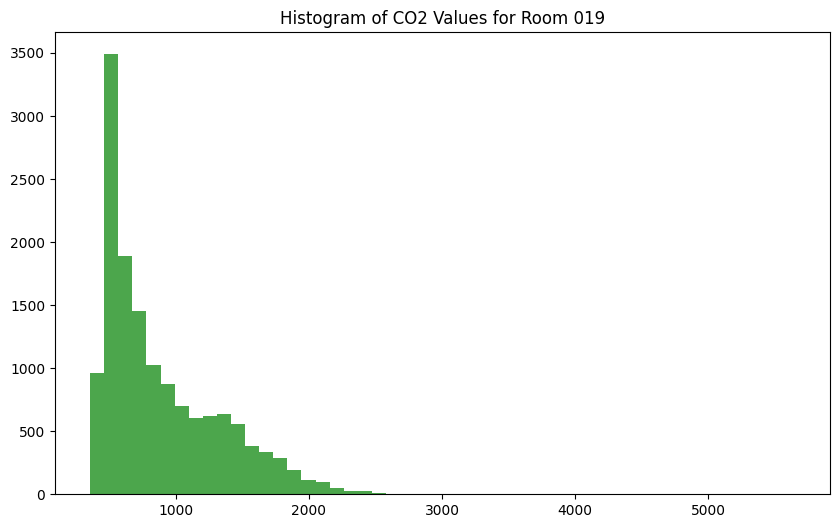

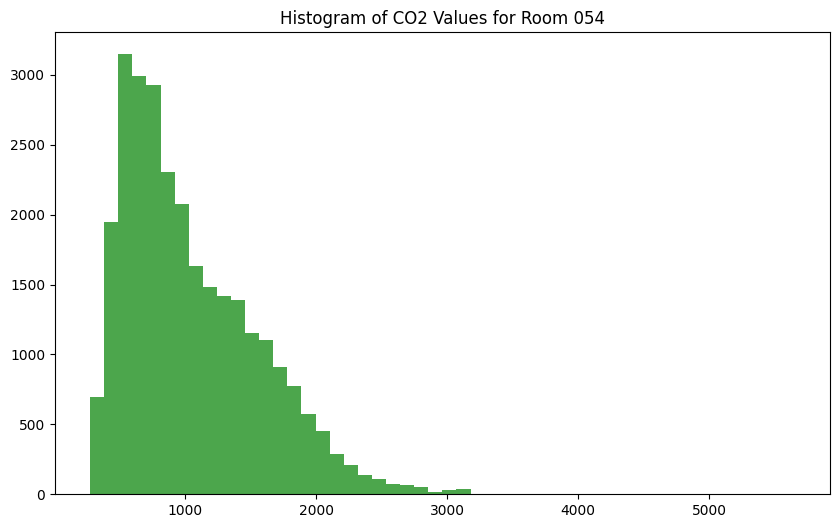

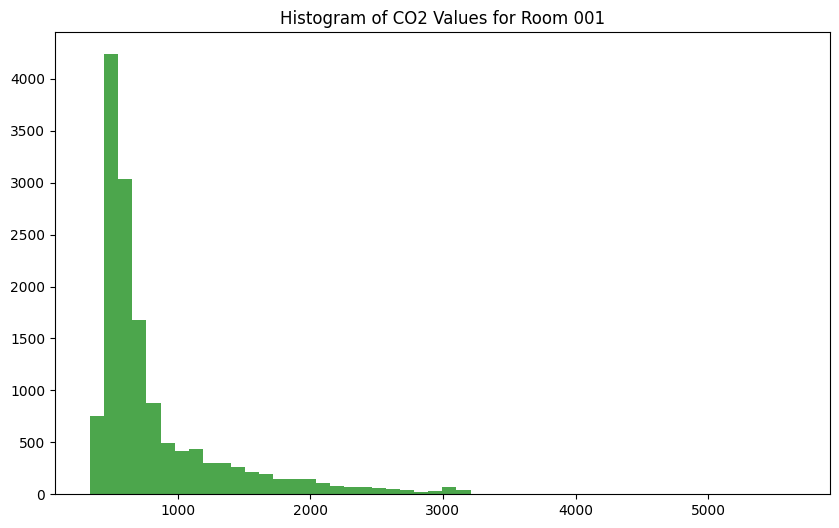

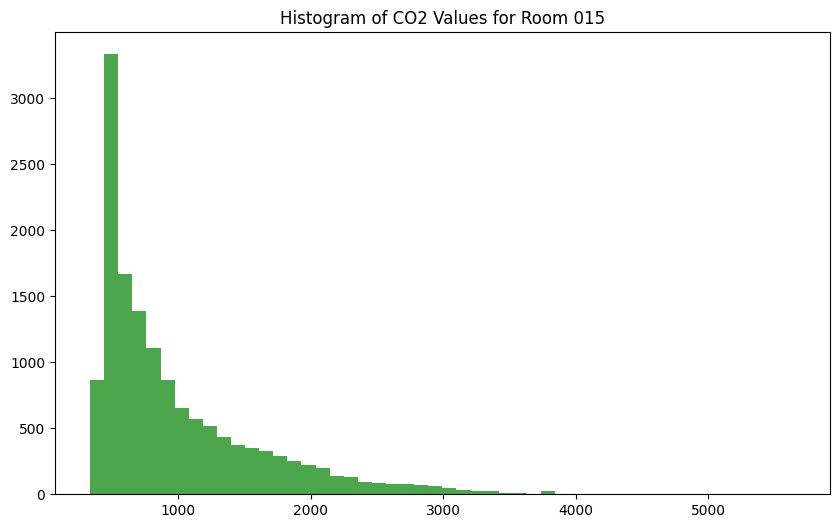

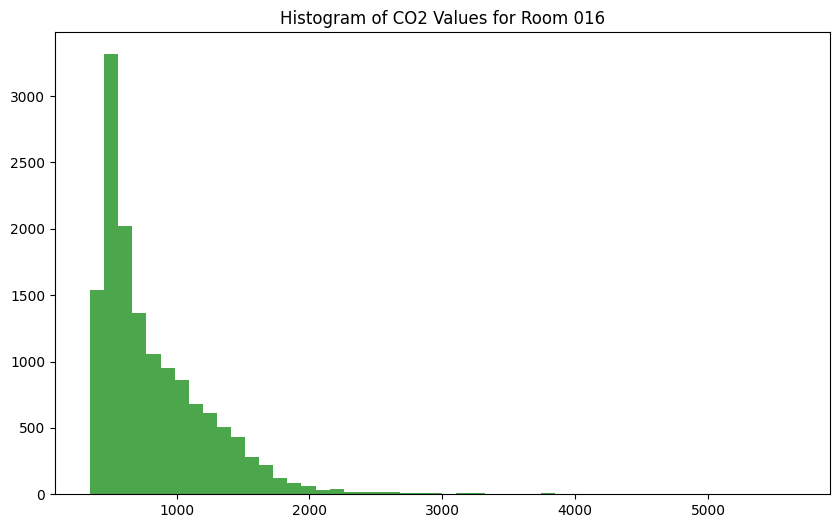

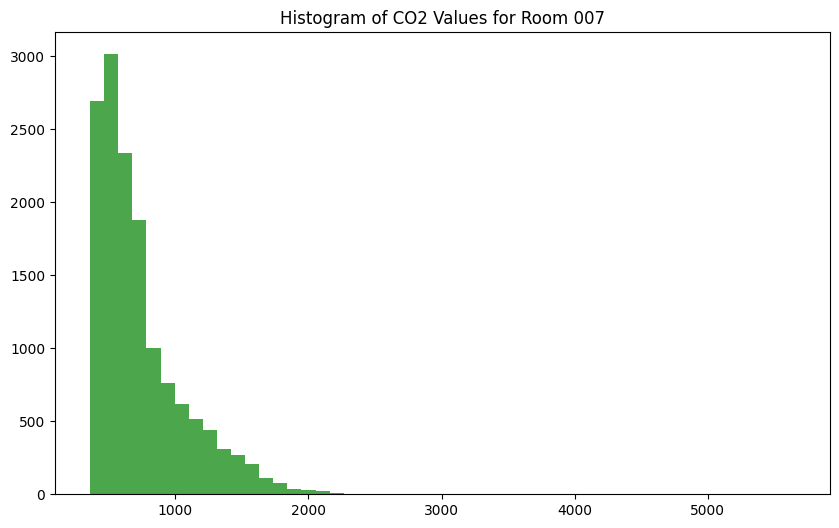

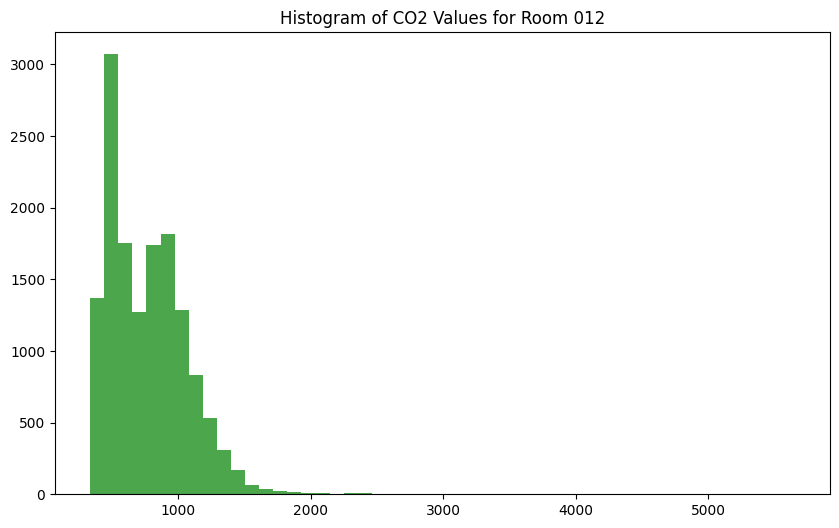

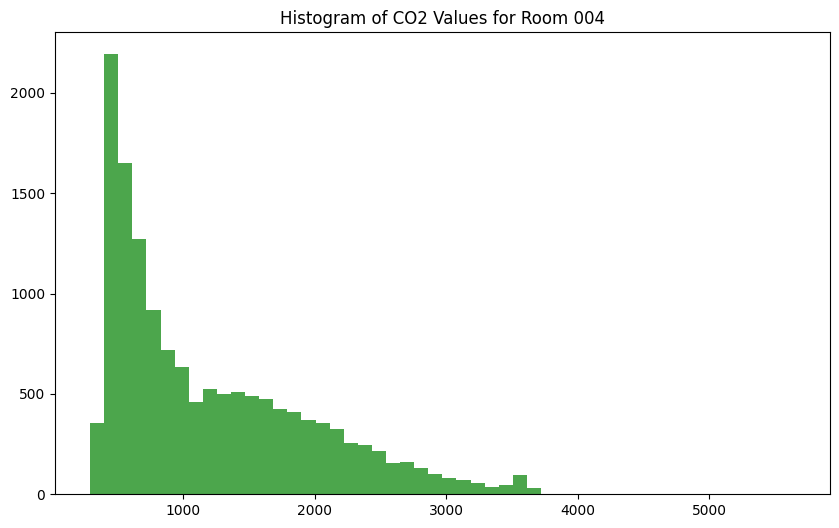

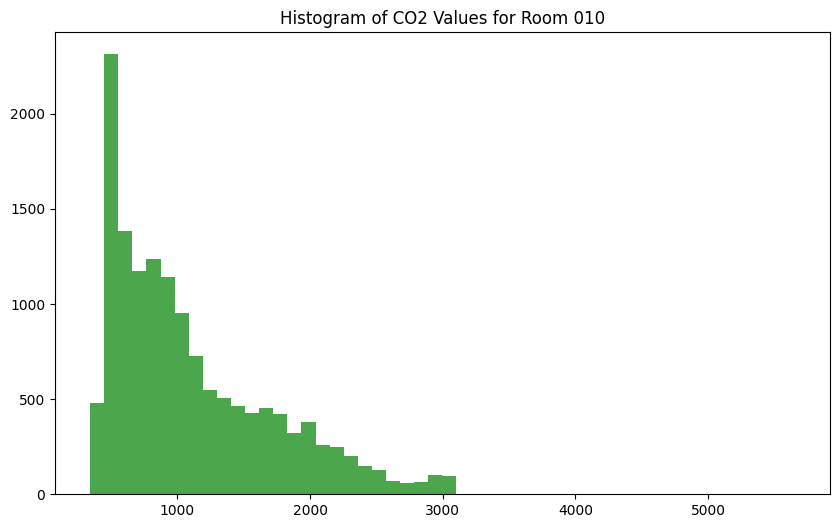

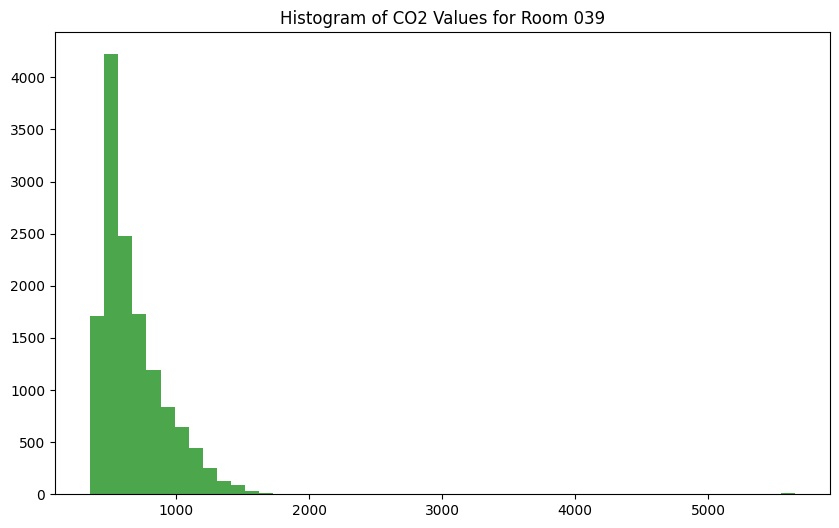

In [10]:


for room_name, series_df in df_series.items():
    # Create histogram of CO2 values
    co2_values = series_df['co2'].dropna()
    plt.figure(figsize=(10, 6))
    plt.hist(co2_values, bins=50, color='green', alpha=0.7)
    plt.title(f"Histogram of CO2 Values for {room_name}")   

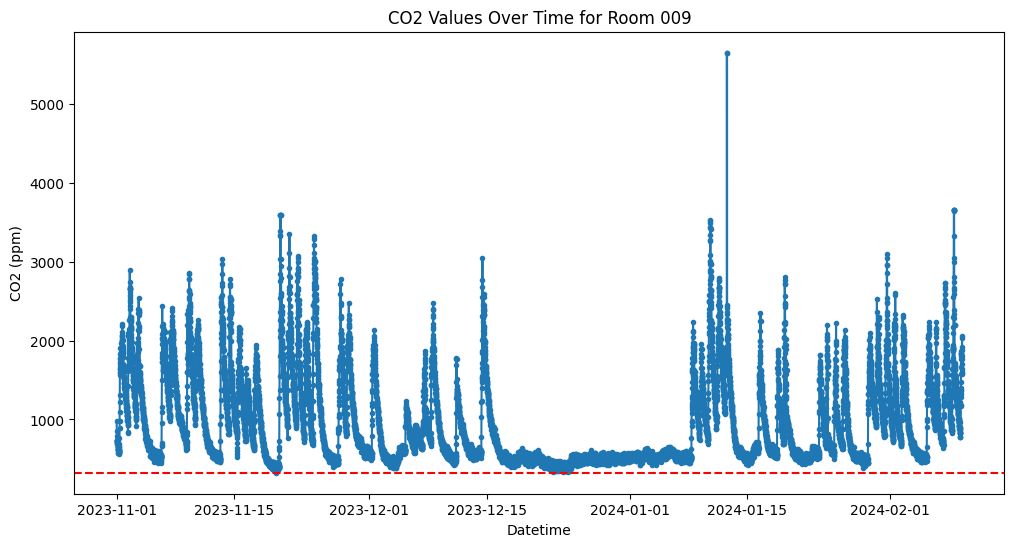

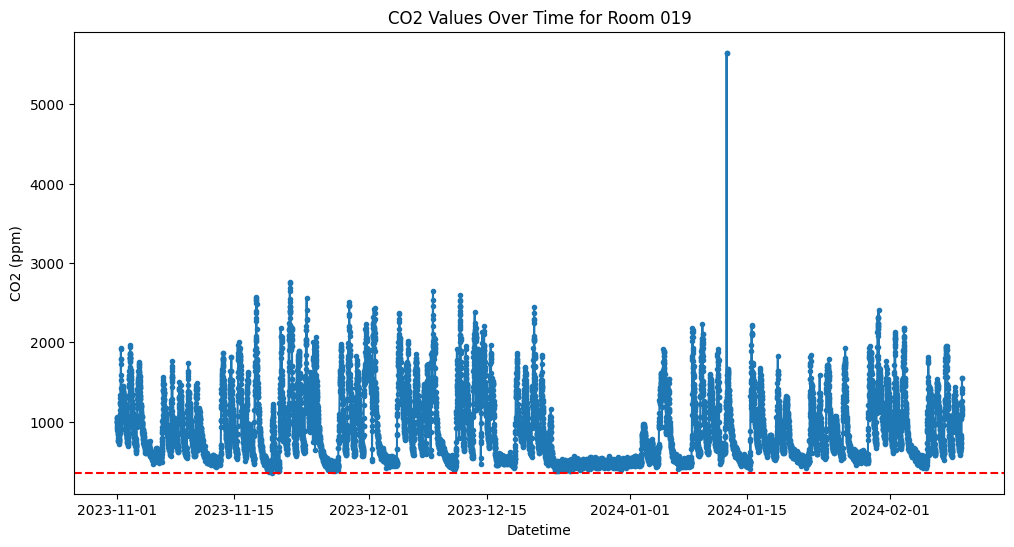

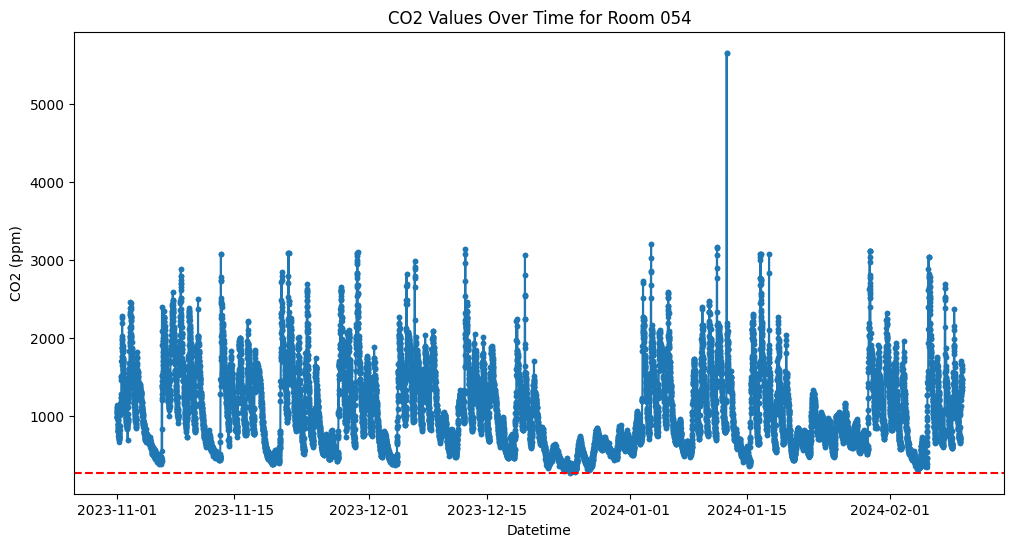

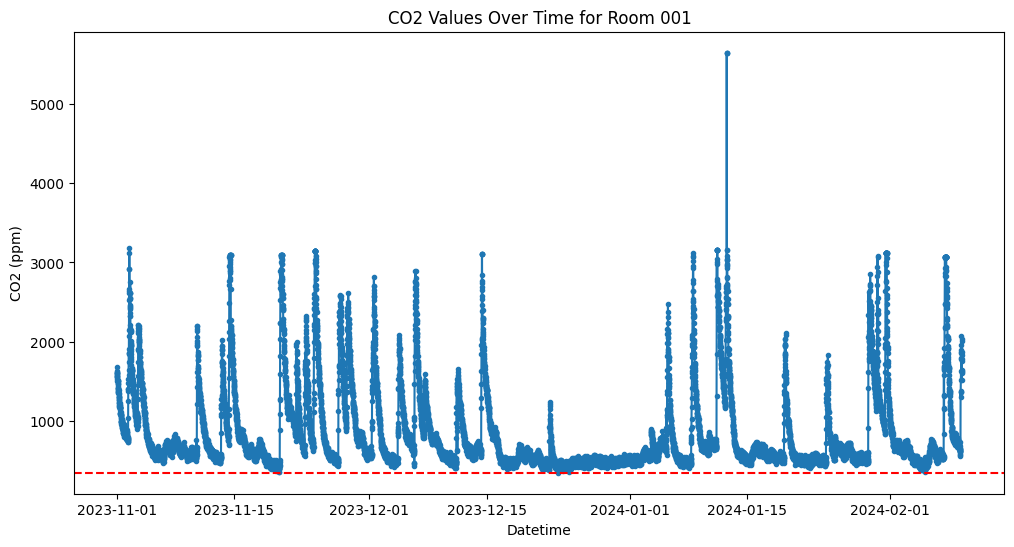

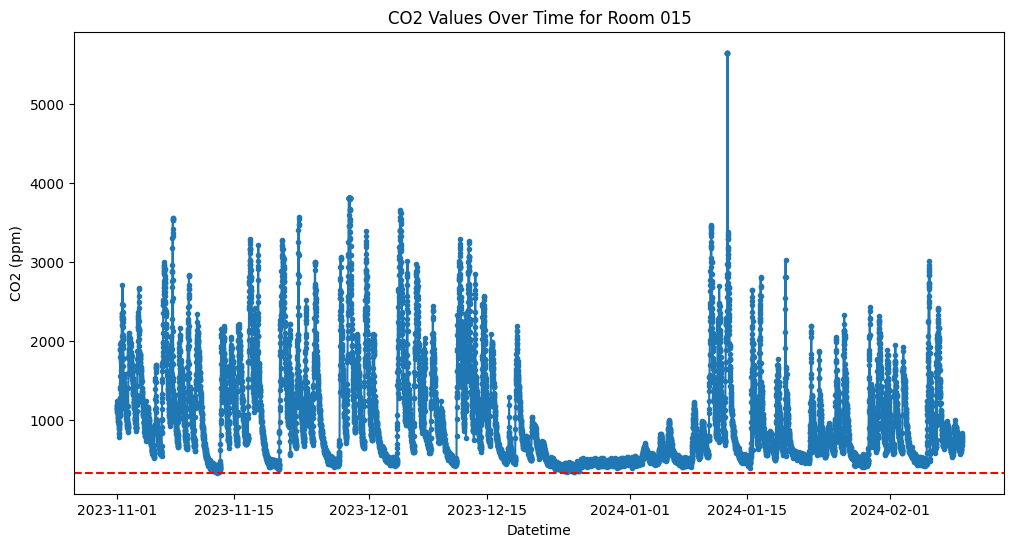

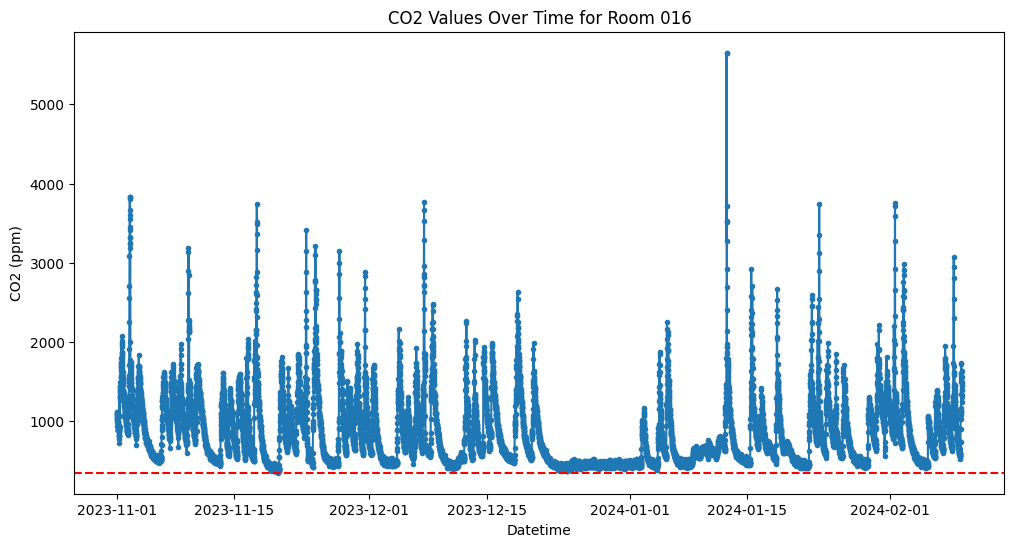

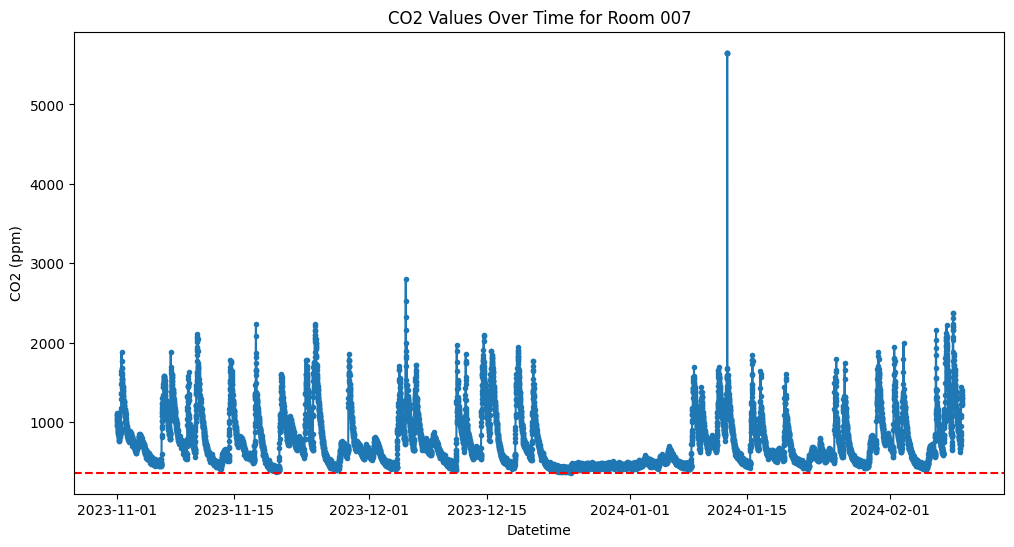

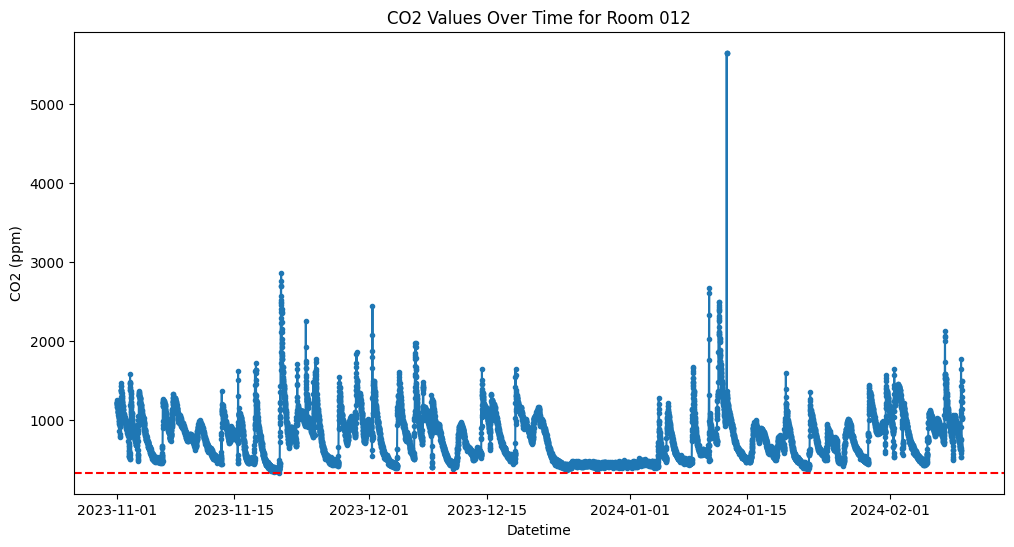

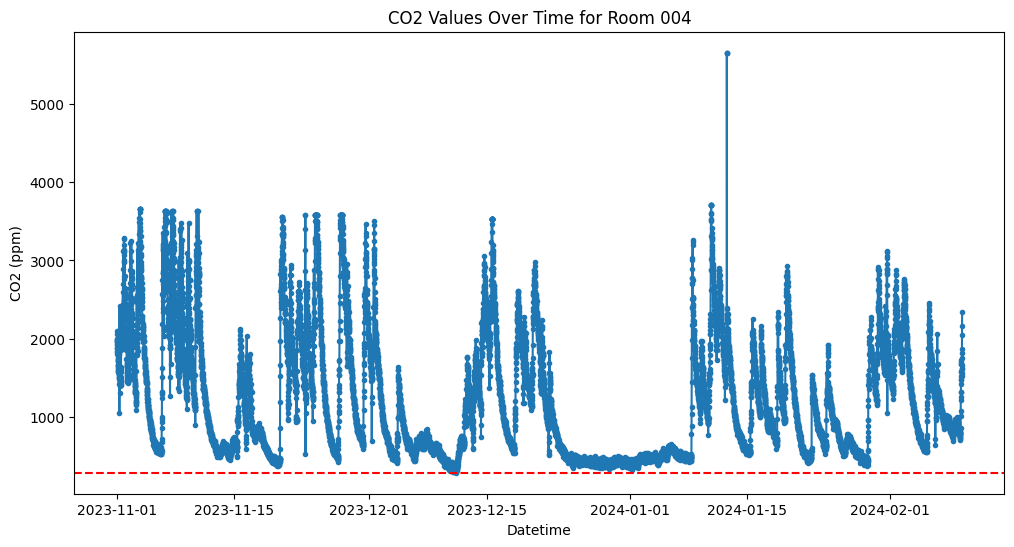

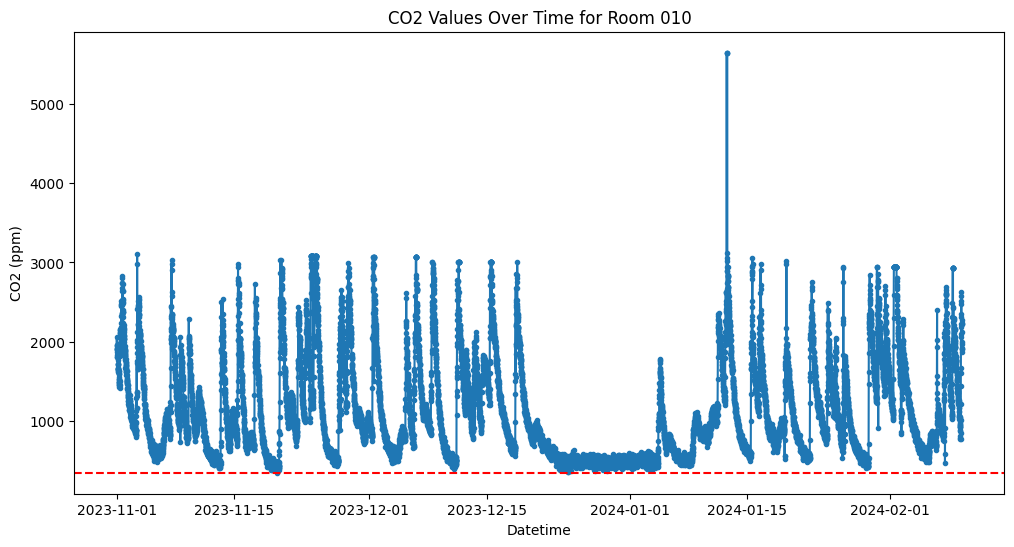

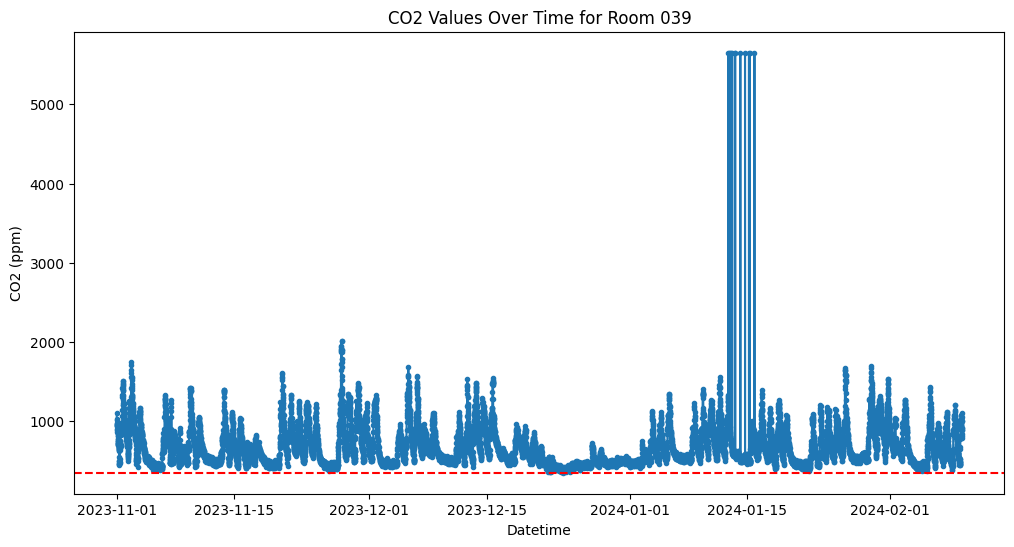

In [11]:
for room_name, series_df in df_series.items():
    # plot the co2 values over time with min value as baseline
    min_val = series_df['co2'].min()
    plt.figure(figsize=(12, 6))
    plt.plot(series_df['datetime'], series_df['co2'], marker='o', linestyle='-', markersize=3)
    plt.axhline(min_val, color='red', linestyle='--', label=f'Min CO2 Value: {min_val:.2f} ppm')
    plt.title(f"CO2 Values Over Time for {room_name}")
    plt.xlabel("Datetime")
    plt.ylabel("CO2 (ppm)")

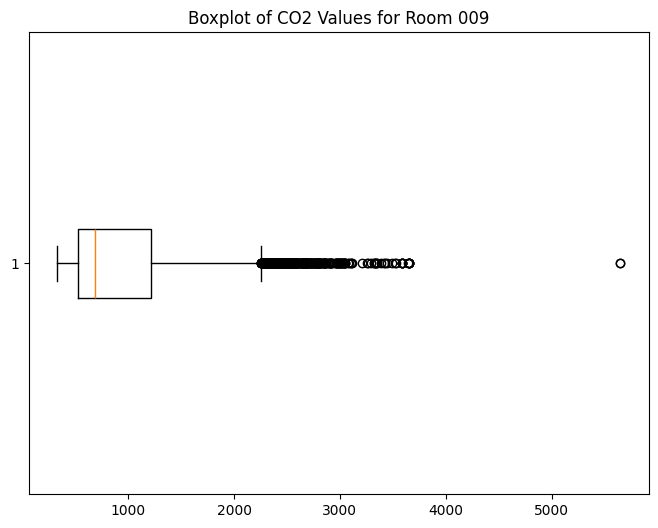

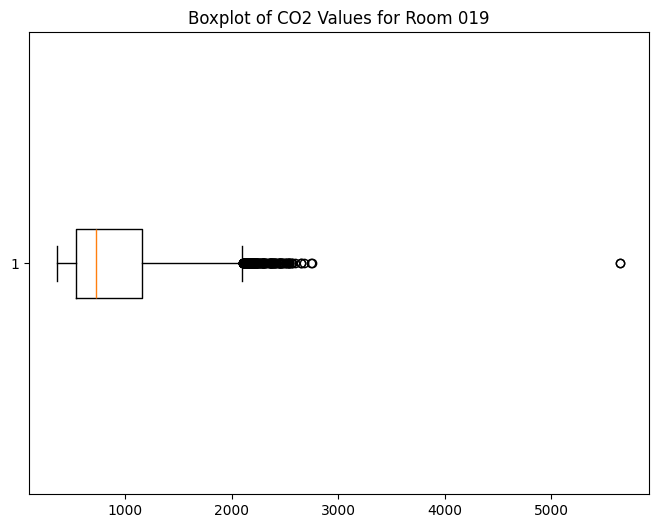

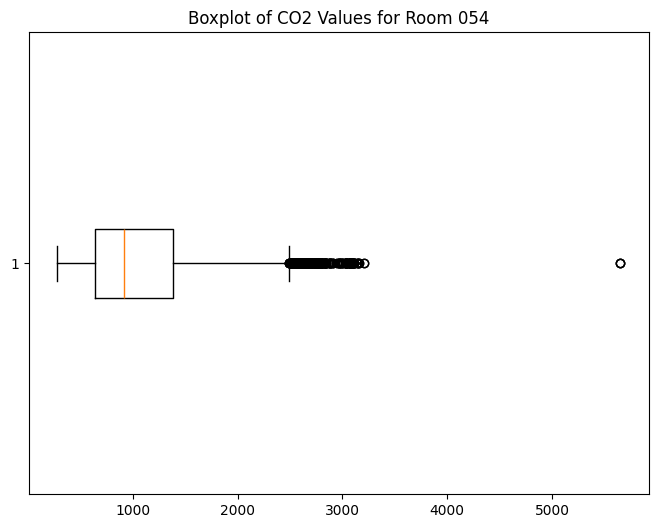

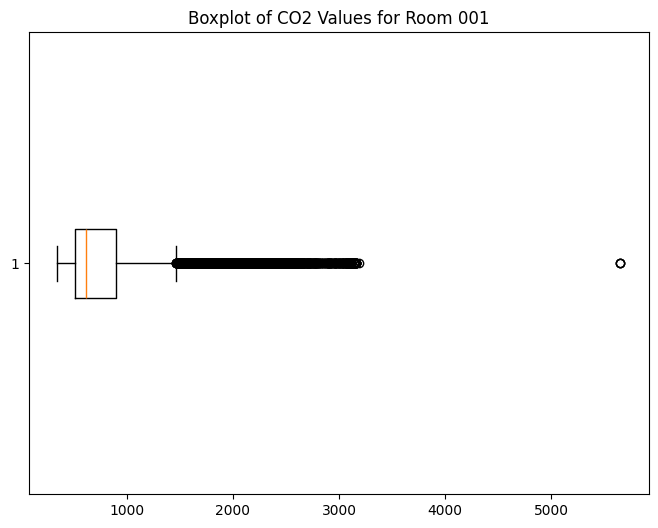

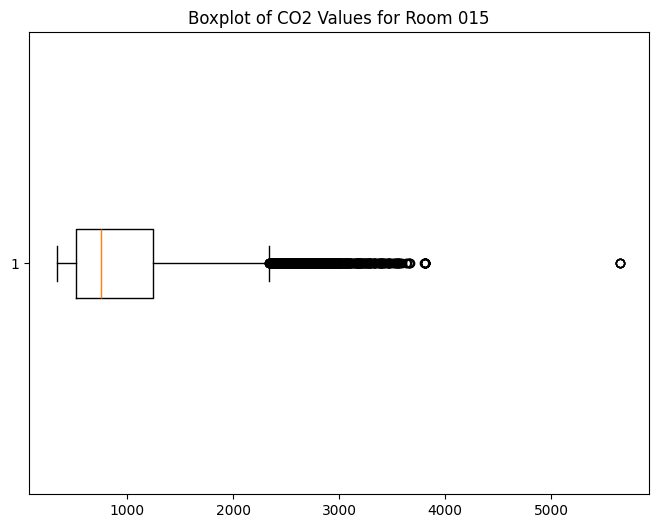

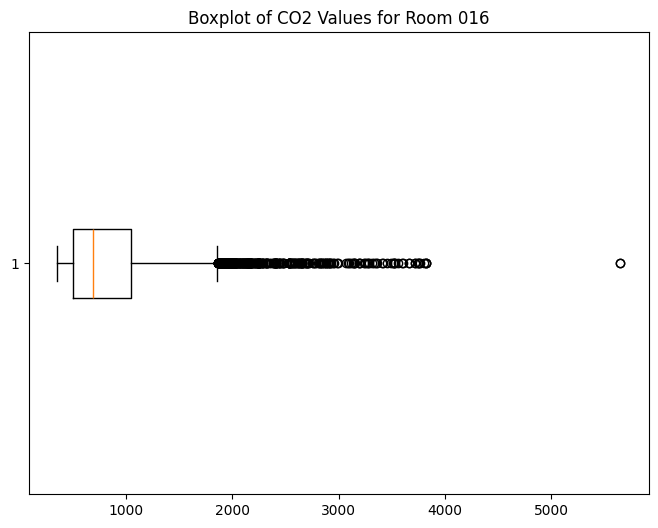

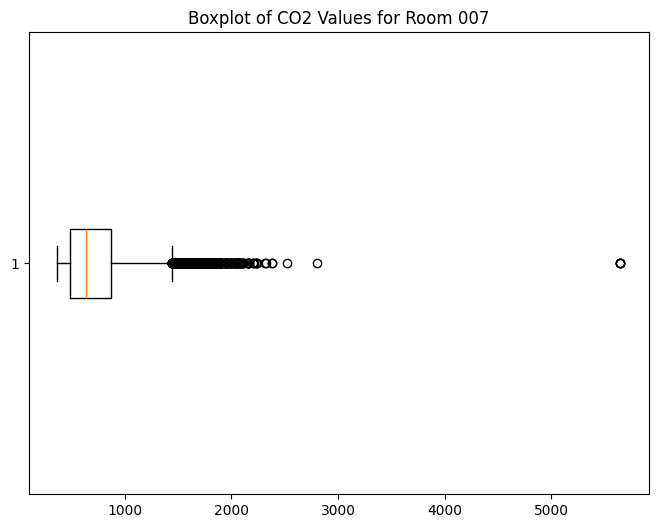

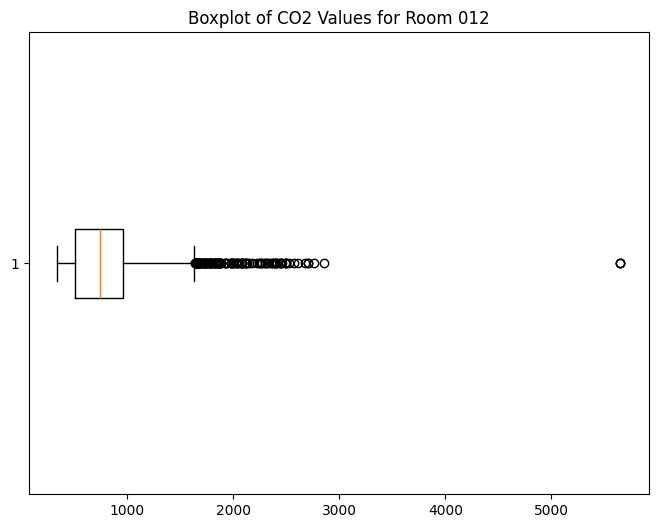

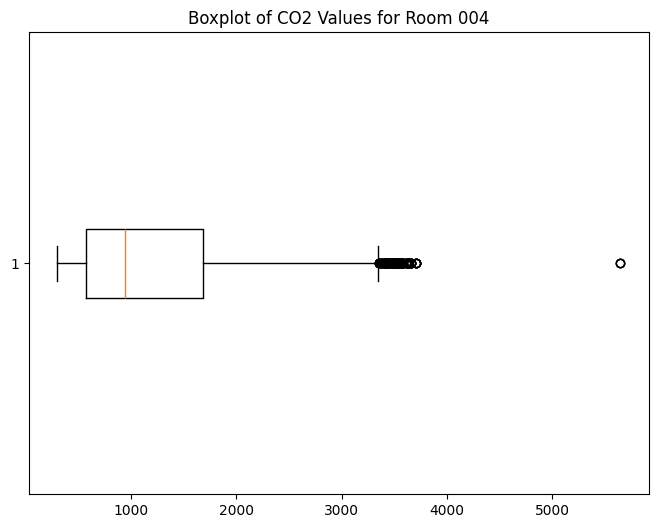

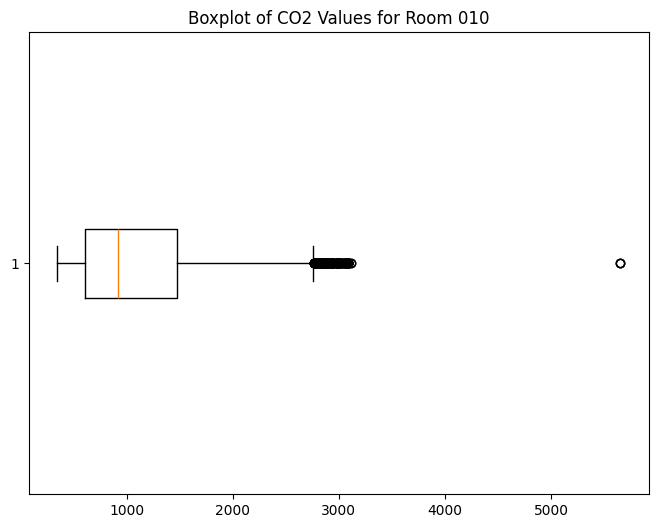

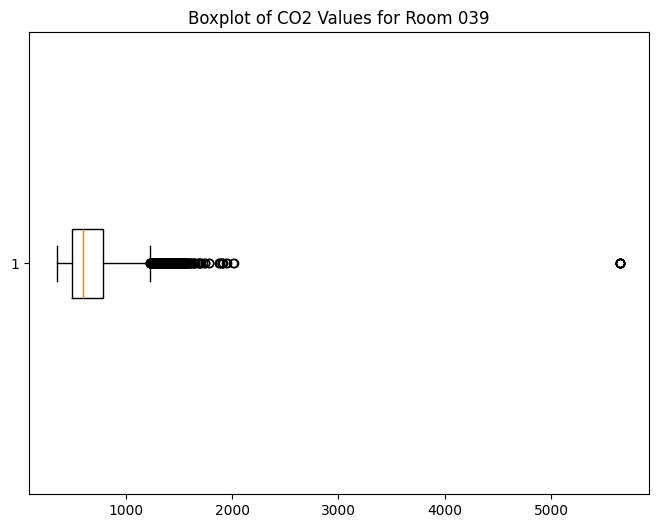

In [12]:
for room_name, series_df in df_series.items(): 
    # Create boxplots of CO2 values$
    plt.figure(figsize=(8, 6))
    plt.boxplot(series_df['co2'].dropna(), vert=False)
    plt.title(f"Boxplot of CO2 Values for {room_name}")

In [13]:
cols_to_keep = ['datetime', 'co2']
for room_name, series_df in df_series.items():
    # Remove observations where CO2 is greater than 3000
    series_df = series_df[series_df['co2'] >= 4000]
    print(f"Room: {room_name}, Remaining observations after removing CO2 > 4000: {len(series_df)}")
    print(series_df[cols_to_keep])


Room: Room 009, Remaining observations after removing CO2 > 4000: 2
                 datetime     co2
27736 2024-01-12 13:42:45  5651.0
27750 2024-01-12 14:03:01  5651.0
Room: Room 019, Remaining observations after removing CO2 > 4000: 2
                 datetime     co2
31088 2024-01-12 13:20:41  5651.0
31092 2024-01-12 13:50:59  5651.0
Room: Room 054, Remaining observations after removing CO2 > 4000: 3
                 datetime     co2
51324 2024-01-12 13:05:58  5651.0
51325 2024-01-12 13:06:06  5651.0
51326 2024-01-12 13:06:39  5651.0
Room: Room 001, Remaining observations after removing CO2 > 4000: 3
                 datetime     co2
17294 2024-01-12 13:13:20  5651.0
17295 2024-01-12 13:14:00  5651.0
17296 2024-01-12 13:14:33  5651.0
Room: Room 015, Remaining observations after removing CO2 > 4000: 5
                 datetime     co2
17402 2024-01-12 14:27:18  5651.0
17404 2024-01-12 14:36:52  5651.0
17406 2024-01-12 14:47:14  5651.0
17407 2024-01-12 14:47:49  5651.0
17412 2024-01-

Because we have severel obs with the exavt same CO2 value on the exact same timestamp, we will first remove duplicates and then look at the summary statistics of the CO2 data.

In [14]:
df_series_cleaned = {}

for room_name, series_df in df_series.items():
    # Drop the 5651 ppm sensor-saturation ceiling (the exact max in every room),
    # then any residual NaNs.
    non_saturated = series_df[series_df["co2"] <= 4000]
    non_saturated = non_saturated[non_saturated["co2"].notna()]

    # Remove exact duplicate (datetime, co2) readings.
    series_df_cleaned = non_saturated.drop_duplicates(subset=['datetime', 'co2'])

    # Store the cleaned DataFrame in the new dictionary
    df_series_cleaned[room_name] = series_df_cleaned

    n_saturated = len(series_df) - len(non_saturated)
    n_duplicates = len(non_saturated) - len(series_df_cleaned)
    print(f"Room: {room_name}, Removed {n_saturated} saturated (>4000 ppm) "
          f"and {n_duplicates} duplicate obs")

Room: Room 009, Removed 2 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 019, Removed 2 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 054, Removed 3 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 001, Removed 3 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 015, Removed 5 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 016, Removed 2 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 007, Removed 4 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 012, Removed 3 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 004, Removed 3 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 010, Removed 3 saturated (>4000 ppm) and 0 duplicate obs
Room: Room 039, Removed 12 saturated (>4000 ppm) and 0 duplicate obs


## Checking for autocorrelation

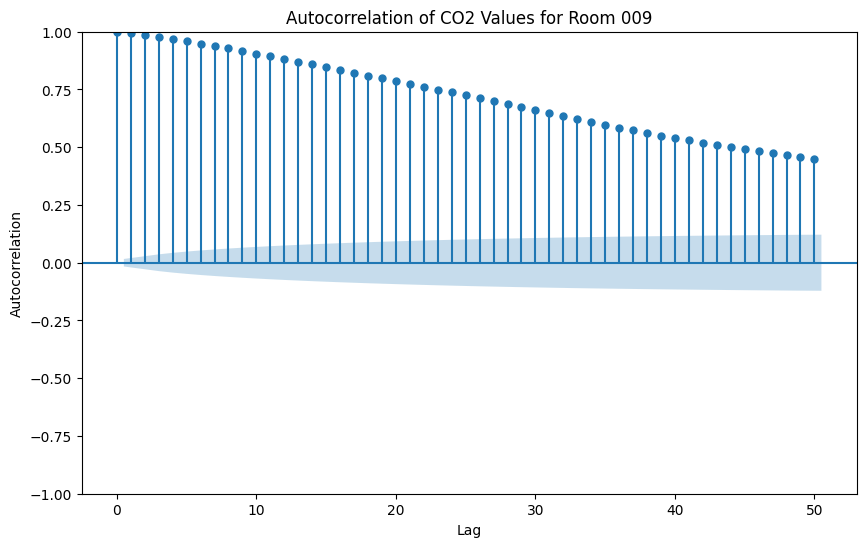

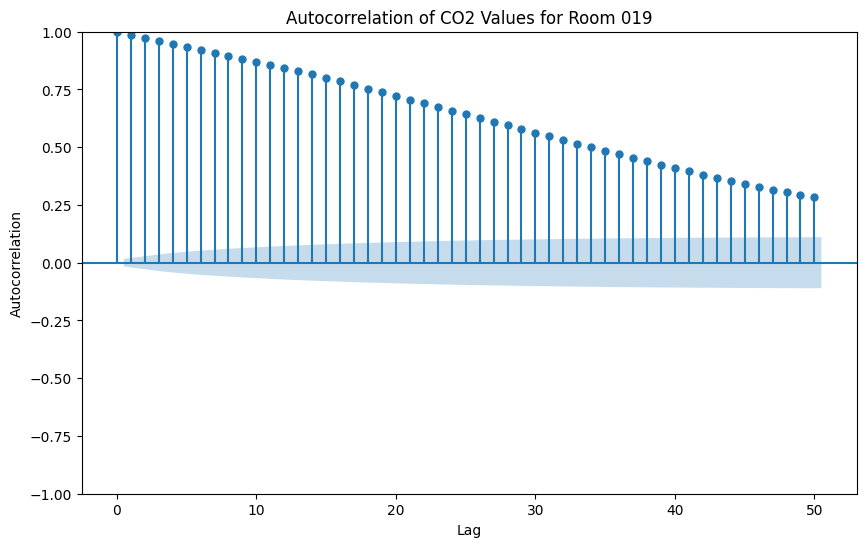

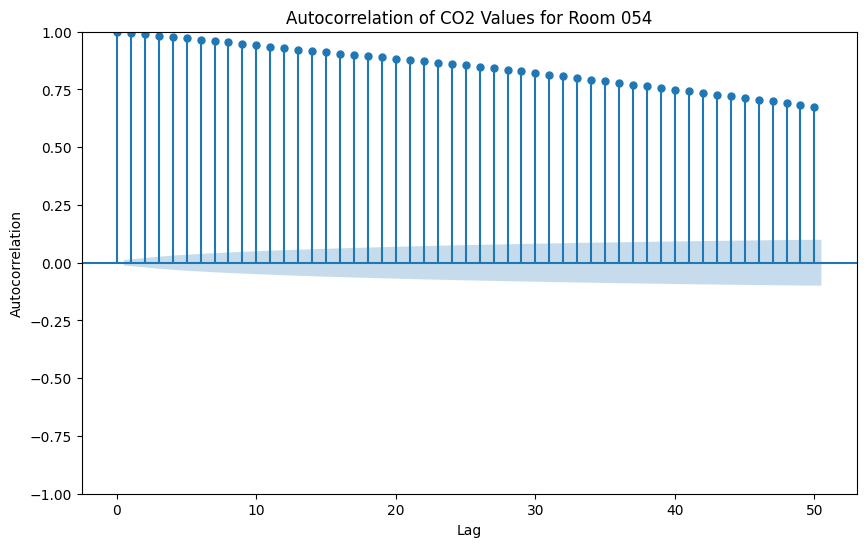

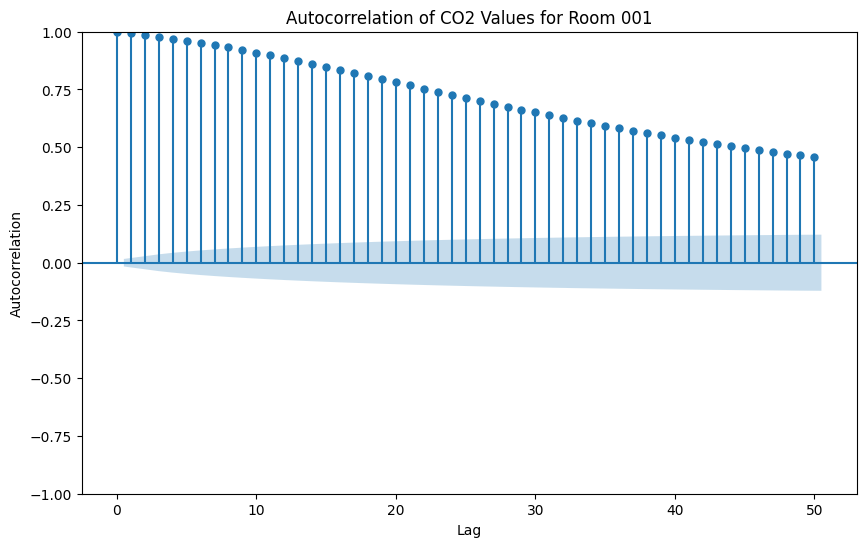

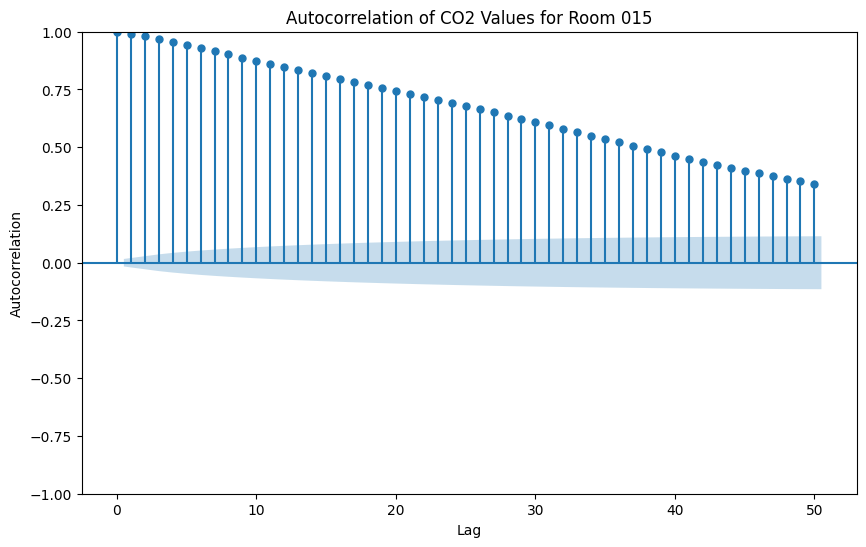

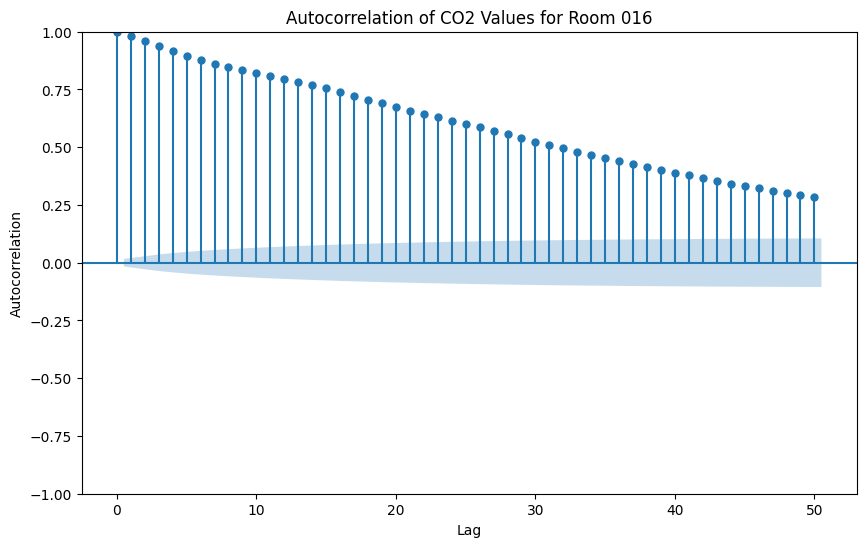

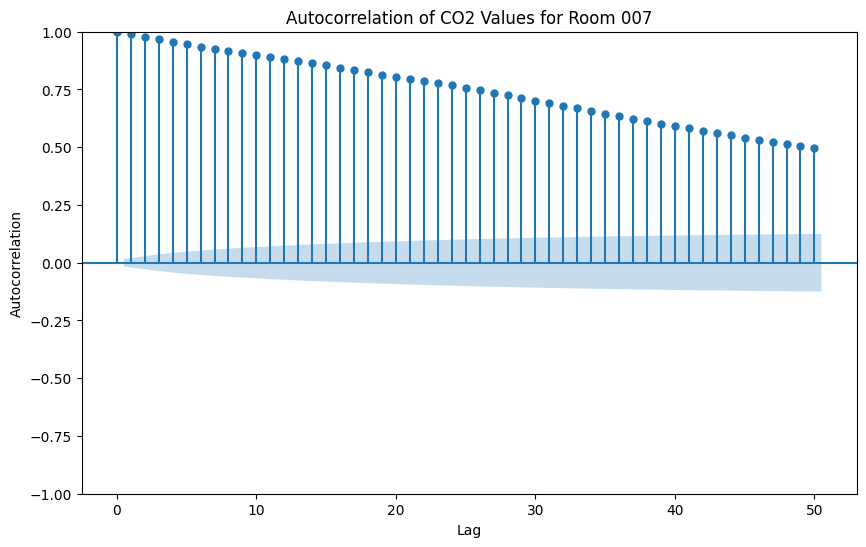

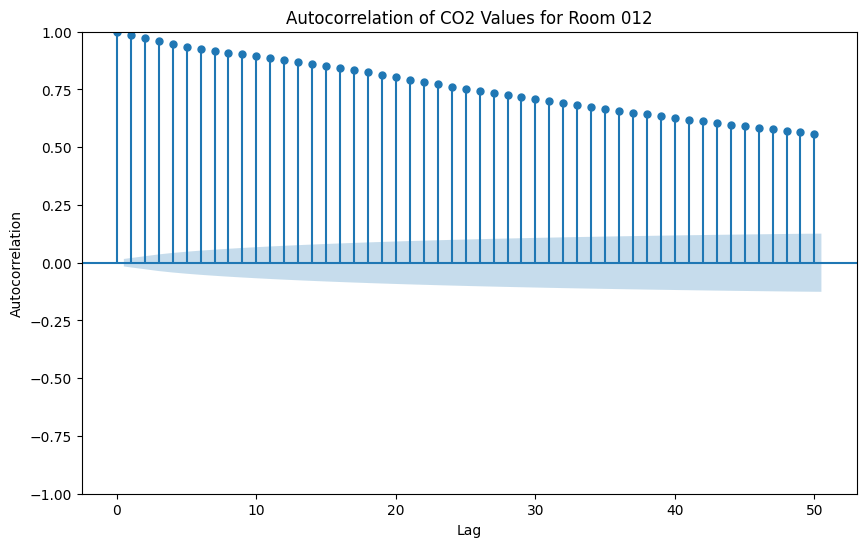

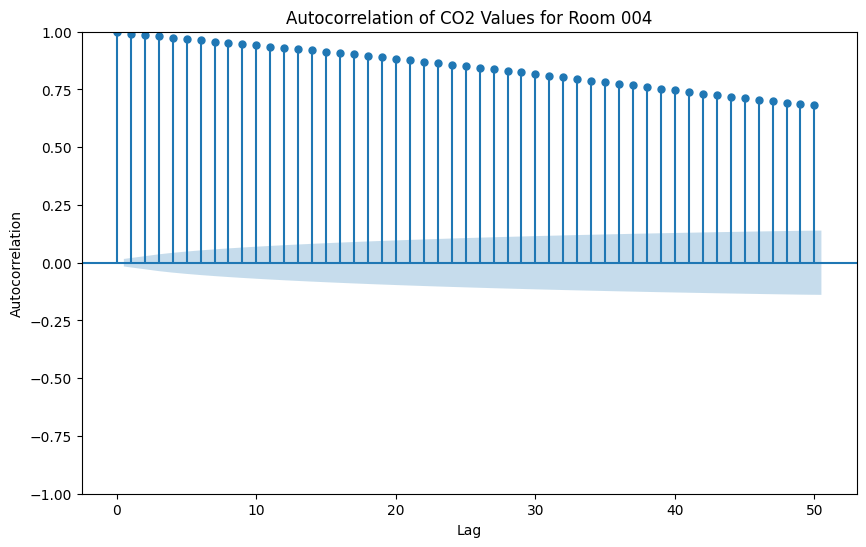

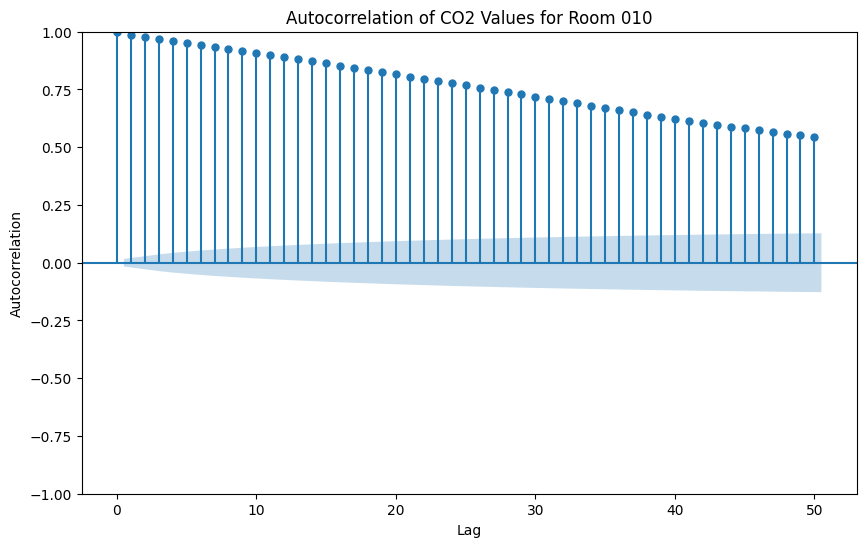

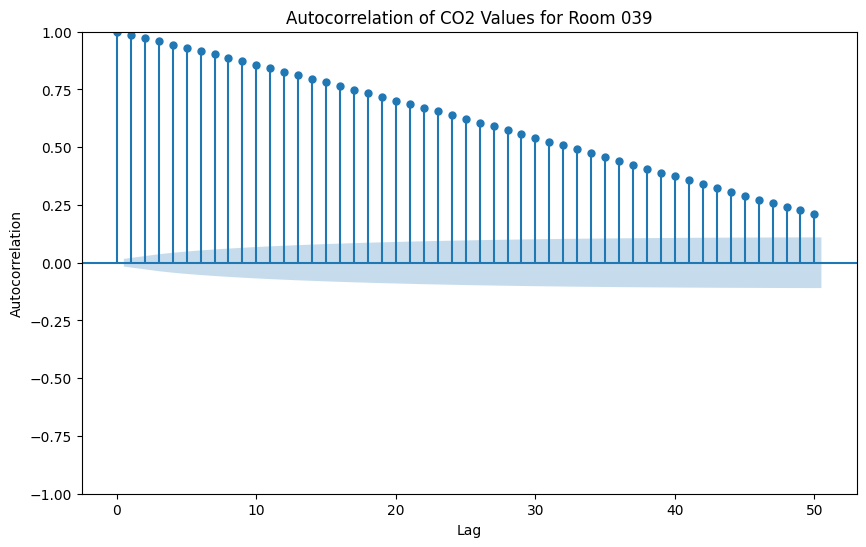

In [15]:
#Plotting autocorrelation plot
for room_name, series_df in df_series_cleaned.items():
    co2_values = series_df['co2']
    plt.figure(figsize=(10, 6))
    sm.graphics.tsa.plot_acf(co2_values, lags=50, ax=plt.gca())
    plt.title(f"Autocorrelation of CO2 Values for {room_name}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()

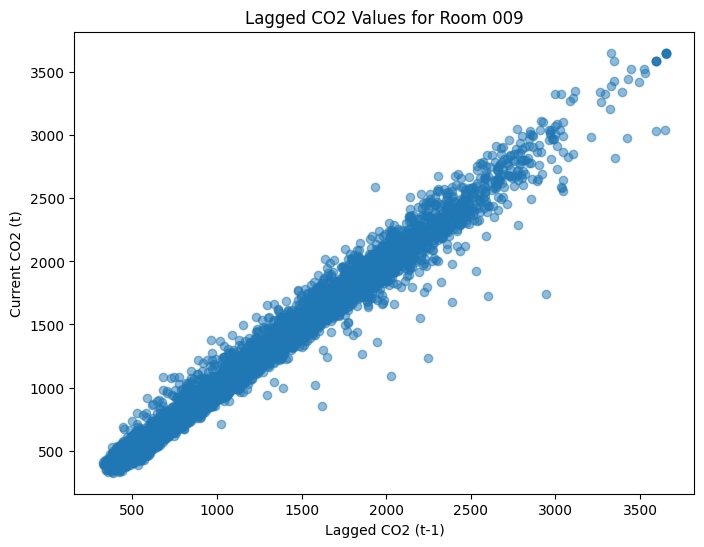

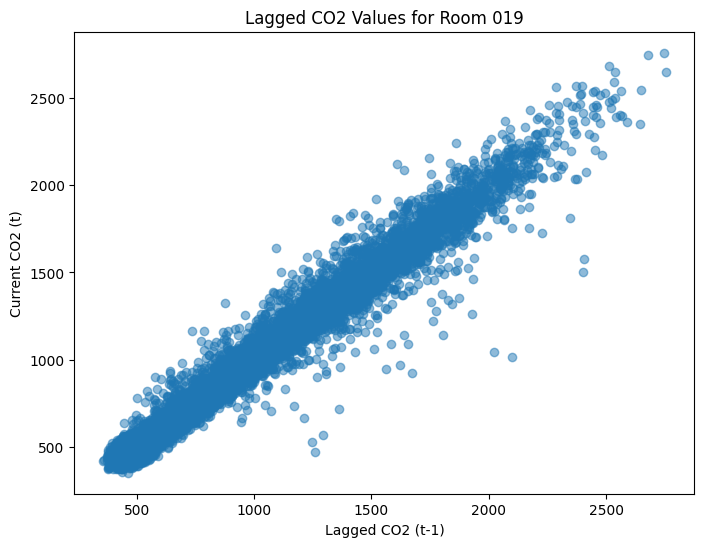

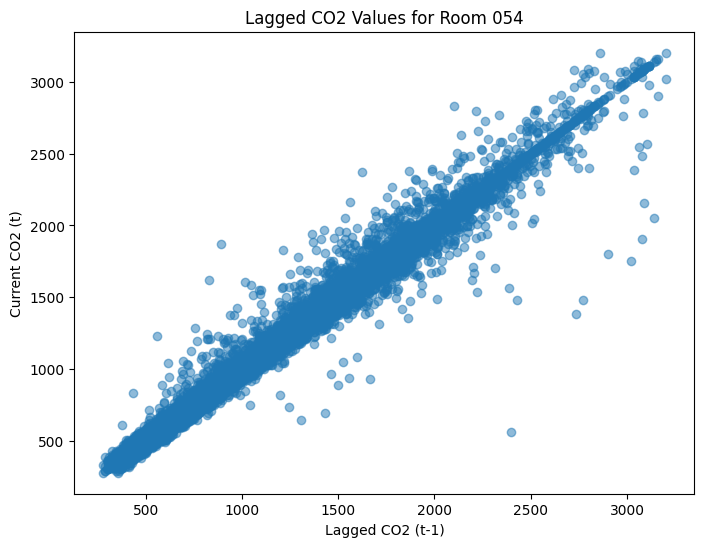

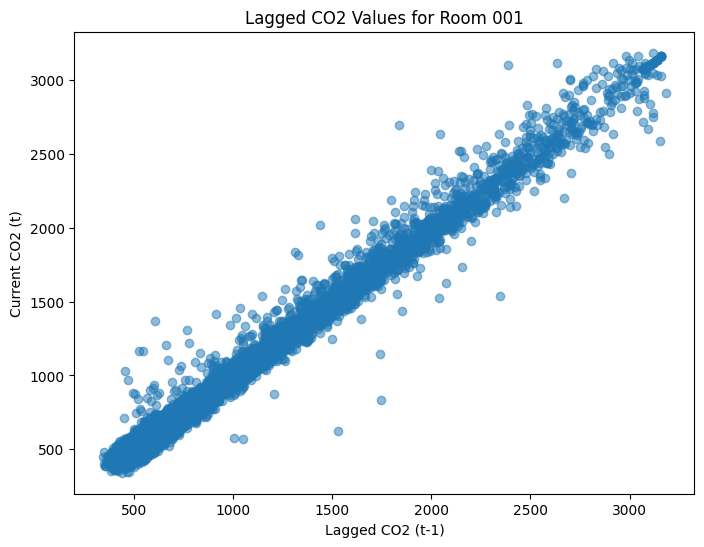

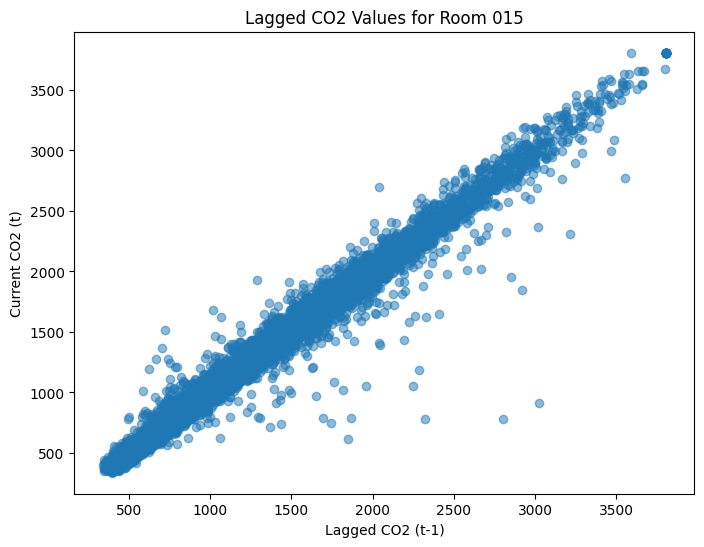

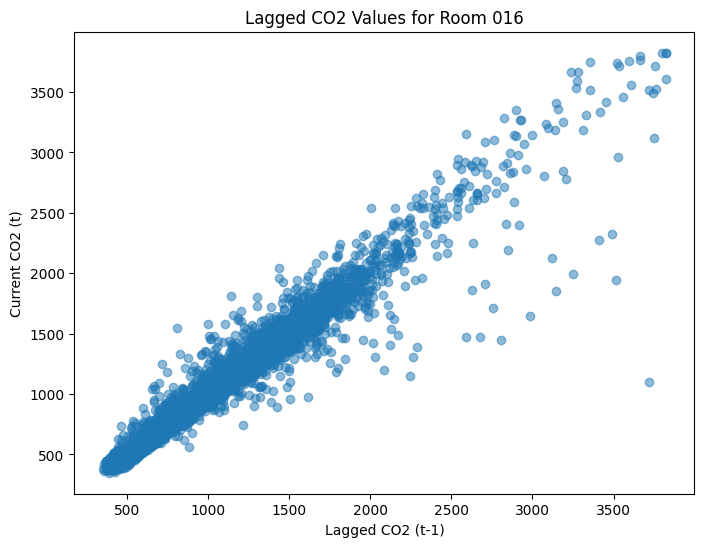

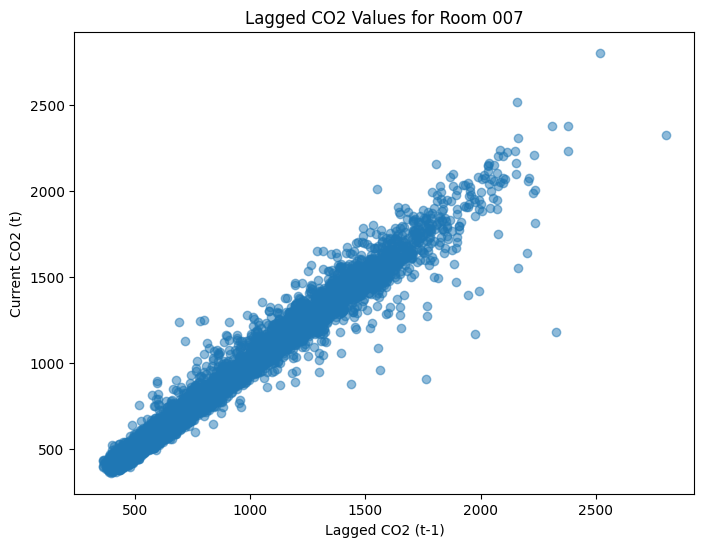

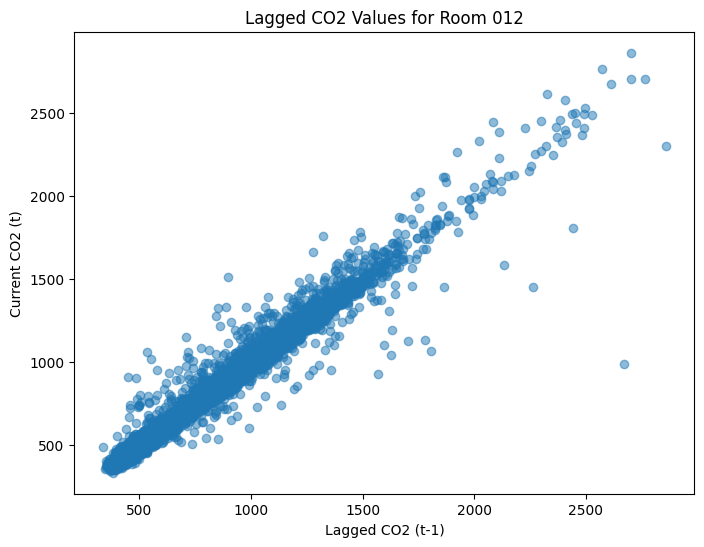

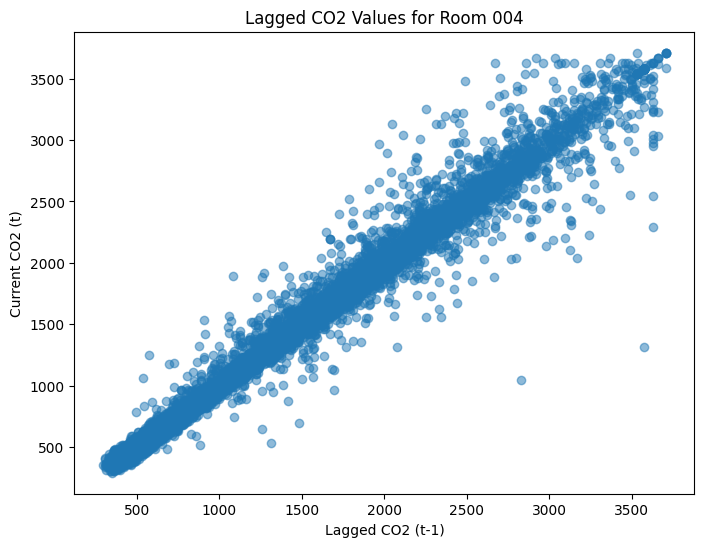

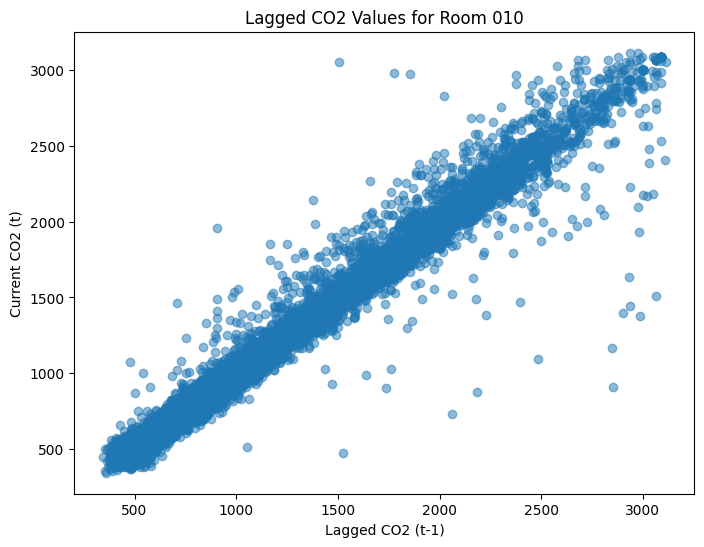

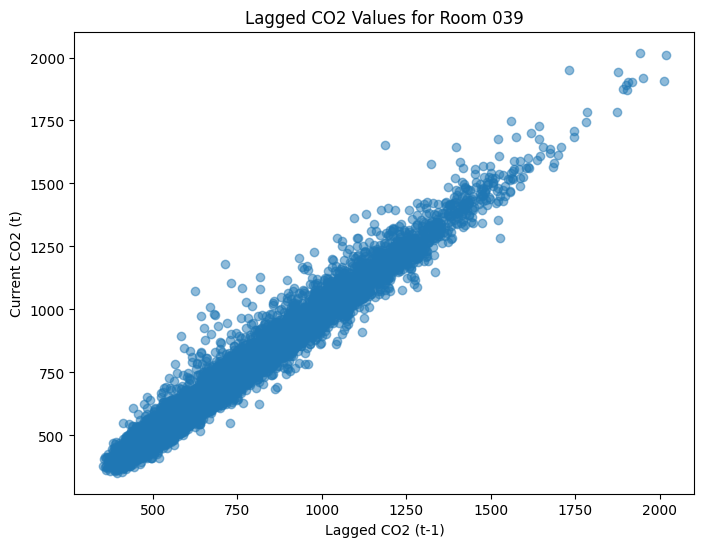

In [16]:
#plotting lagged 1 vs current 

for room_name, series_df in df_series_cleaned.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(series_df['co2'].shift(1), series_df['co2'], alpha=0.5)
    plt.title(f"Lagged CO2 Values for {room_name}")
    plt.xlabel("Lagged CO2 (t-1)")
    plt.ylabel("Current CO2 (t)")
    plt.show()

In [17]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

SECONDS_PER_OBS = 600


for room_name, series_df in df_series_cleaned.items():
    data = series_df['co2'].values  # your 1D array of residuals or a time series
    result = acorr_ljungbox(data, lags=[2000], return_df=True)

    print(f"Ljung-Box test results for {room_name}:")
    print(result)
    print()

Ljung-Box test results for Room 009:
           lb_stat  lb_pvalue
2000  1.305408e+06        0.0

Ljung-Box test results for Room 019:
           lb_stat  lb_pvalue
2000  1.359706e+06        0.0

Ljung-Box test results for Room 054:
           lb_stat  lb_pvalue
2000  3.788332e+06        0.0

Ljung-Box test results for Room 001:
           lb_stat  lb_pvalue
2000  684300.96919        0.0

Ljung-Box test results for Room 015:
           lb_stat  lb_pvalue
2000  1.332180e+06        0.0

Ljung-Box test results for Room 016:
           lb_stat  lb_pvalue
2000  907743.50371        0.0

Ljung-Box test results for Room 007:
            lb_stat  lb_pvalue
2000  911155.652372        0.0

Ljung-Box test results for Room 012:
           lb_stat  lb_pvalue
2000  1.022666e+06        0.0

Ljung-Box test results for Room 004:
           lb_stat  lb_pvalue
2000  1.658010e+06        0.0

Ljung-Box test results for Room 010:
           lb_stat  lb_pvalue
2000  1.060995e+06        0.0

Ljung-Box test res

In [18]:
from statsmodels.tsa.stattools import pacf
import numpy as np

nlags = 50  # pick something reasonable for your sampling rate


for room_name, series_df in df_series_cleaned.items():
    data = series_df['co2'].values  # your 1D array of residuals or a time series
    pacf_vals = pacf(data, nlags=nlags, method='ywadjusted')

    # 95% confidence bound under the null of "no partial autocorrelation"
    n = len(data)
    conf_bound = 1.96 / np.sqrt(n)
    # Find the last lag where PACF is still significant
    significant_lags = np.where(np.abs(pacf_vals) > conf_bound)[0]
    last_significant = significant_lags.max() if len(significant_lags) > 0 else 0
    print(f"Room: {room_name}, Last significant lag: {last_significant}")

Room: Room 009, Last significant lag: 28
Room: Room 019, Last significant lag: 38
Room: Room 054, Last significant lag: 47
Room: Room 001, Last significant lag: 41
Room: Room 015, Last significant lag: 36
Room: Room 016, Last significant lag: 29
Room: Room 007, Last significant lag: 33
Room: Room 012, Last significant lag: 45
Room: Room 004, Last significant lag: 42
Room: Room 010, Last significant lag: 39
Room: Room 039, Last significant lag: 41


In [19]:
#FIRST_OBS = 100
#
#for room_name, data in df_series_cleaned.items():
#    #Finting the gradient of the co2 values 
#    waiting_time = data['datetime'].diff().dt.total_seconds()
#    gradient = np.gradient(data['co2'].values, waiting_time.fillna(SECONDS_PER_OBS).values)  # Use SECONDS_PER_OBS for the first value
#
#    print(f"Room: {room_name}, Gradient of CO2 values:")
#    plt.figure(figsize=(10, 6))
#    plt.plot(data['datetime'][:FIRST_OBS], gradient[:FIRST_OBS], label='Gradient of CO2', color='blue')
#    plt.title(f"Gradient of CO2 Values for {room_name}")
#    plt.xlabel("Datetime")
#    plt.ylabel("Gradient of CO2")
#    plt.legend()
#    plt.show()

# Fitting Models

We now fit Hidden Markov Models to the CO2 data.

The models we fit are:
1. Gaussian HMM with discrete static transitions (`StaticTransition`)
2. Gaussian HMM with continuous-time static transitions (`ContinuousStaticTransition`)
3. Gaussian HMM with continuous-time, covariate-driven (dynamic) transitions (`ContinuousDynamicTransition`)

In [20]:
from src.api.v4 import HMM, GaussEmission, ContinuousStaticTransition, StaticTransition
import jax.numpy as jnp
from sklearn.model_selection import TimeSeriesSplit
import copy

print(df_series_cleaned.keys())

dict_keys(['Room 009', 'Room 019', 'Room 054', 'Room 001', 'Room 015', 'Room 016', 'Room 007', 'Room 012', 'Room 004', 'Room 010', 'Room 039'])


In [21]:
#Config 
room_name = "Room 009" 
STATES = 4 
TEST_SIZE = 0.2
SECONDS = 600


In [22]:
#Extracting data 
series_df = df_series_cleaned[room_name] 

N = len(series_df) 

# Train on the first (1 - TEST_SIZE) of the series, hold out the last TEST_SIZE.
TRAIN_IDX = int(N * (1 - TEST_SIZE))

ys = jnp.asarray(series_df['co2'].values)
ts = jnp.asarray(series_df['datetime'].diff().dt.total_seconds().fillna(600).values, dtype = int)  

ts = ts / SECONDS  # Convert to number of observations (waiting time in units of ~600 s)

ys_train, ys_test = ys[:TRAIN_IDX], ys[TRAIN_IDX:]
ts_train, ts_test = ts[:TRAIN_IDX], ts[TRAIN_IDX:] 

In [23]:
def train_hmm(ys_train, ts_train, hmm: HMM, t_pred, tol = 1e-4, n_splits = 5, xs_train=None, init_models=None):
    # test_size must leave room for the first training fold: with n_splits
    # validation blocks we need (n_splits + 1) blocks total, so cap the block
    # size at len // (n_splits + 1) to avoid "Too many splits" from sklearn.
    #
    # gap=0: the validation block starts on the observation immediately after
    # the training block, so t_pred horizon i aligns with ys_val_fold[i]
    # (horizon 1 == the first held-out observation). A non-zero gap would offset
    # the forecast horizons from the targets they're scored against.
    #
    # xs_train (optional): covariate matrix aligned with ys_train. When given it
    # is sliced per fold and threaded through fit / forecast, so a covariate-
    # driven model (e.g. ContinuousDynamicTransition) is CV-trained exactly like
    # the covariate-free models. When None the covariates are simply ignored.
    #
    # init_models (optional): a per-fold list of starting HMMs (len == n_splits).
    # Fold i is trained from init_models[i] instead of the shared `hmm` template,
    # which lets an expensive model warm-start from a cheaper fit on the same
    # fold (e.g. the continuous-static optimum) so LBFGS converges in far fewer
    # iterations. When None every fold starts from `hmm`.
    test_size = len(ys_train) // (n_splits + 1)
    tsv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=0)

    if init_models is not None and len(init_models) != n_splits:
        raise ValueError(
            f"init_models must have one model per fold: got {len(init_models)} for n_splits={n_splits}."
        )

    rmses = []
    r2s = [] 
    models = []

    for i, (train_idx, val_idx) in enumerate(tsv.split(ys_train)):
        ys_train_fold, ys_val_fold = ys_train[train_idx], ys_train[val_idx]
        ts_train_fold, ts_val_fold = ts_train[train_idx], ts_train[val_idx]

        # Covariates aligned with the fold indices (None for covariate-free models).
        if xs_train is not None:
            xs_train_fold, xs_val_fold = xs_train[train_idx], xs_train[val_idx]
        else:
            xs_train_fold = xs_val_fold = None

        # Starting point for this fold: a per-fold warm start if supplied, else
        # a fresh copy of the shared template.
        template = init_models[i] if init_models is not None else hmm
        hmm_fold = copy.deepcopy(template)

        # Fit the HMM on the training fold
        hmm_fold.fit(ys=ys_train_fold, ts=ts_train_fold, xs=xs_train_fold, tol=tol)

        # Forecast the emission at the requested horizons (absolute distances
        # from the last training observation) and align to the matching
        # validation targets. `ts_train_fold` is passed so the continuous model
        # anchors on the correctly-spaced filtered state; for a covariate-driven
        # model `x_pred` supplies the future covariates at each forecast step.
        x_pred = xs_val_fold[:len(t_pred)] if xs_val_fold is not None else None
        preds = hmm_fold.predict_emission(
            t_pred=t_pred, ys=ys_train_fold, ts=ts_train_fold,
            xs=xs_train_fold, x_pred=x_pred,
        )
        n = min(len(preds), len(ys_val_fold))
        preds, y_true = preds[:n], ys_val_fold[:n]

        fold_rmse = rmse(y_true, preds)
        fold_r2 = r2_score(y_true, preds)
        rmses.append(fold_rmse)
        r2s.append(fold_r2)
        models.append(hmm_fold)

        # Evaluate held-out likelihood on the validation fold
        log_likelihood = hmm_fold.log_likelihood(ys_val_fold, ts=ts_val_fold, xs=xs_val_fold)

        print(f"Fold: {i}, RMSE: {float(fold_rmse):.4f}, R2: {float(fold_r2):.4f}")
        print(f"Fold Log-Likelihood: {log_likelihood}")

    print(f"Mean RMSE: {float(jnp.mean(jnp.array(rmses))):.4f}, "
          f"Mean R2: {float(jnp.mean(jnp.array(r2s))):.4f}")
    return rmses, r2s, models



def rmse(y_true, y_pred):
    return jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)) 

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) 


## Cross-validated training of the discrete and continuous models

We train both a discrete (`StaticTransition`) and a continuous
(`ContinuousStaticTransition`) Gaussian HMM with `train_hmm`. `t_pred` gives the
forecast horizons as absolute distances from the last training observation, in
the same time units as `ts` (waiting time / `SECONDS`, i.e. ~1.0 per step). Both
models therefore forecast the same `[1..10]`-step horizons, so their RMSE / R²
are directly comparable.

In [24]:
# Shared emission and base transition for the cross-validation runs
emission_cv = GaussEmission.from_params(
    jnp.quantile(ys, jnp.linspace(0.05, 0.95, STATES)),
    jnp.std(ys) * jnp.ones(STATES),
)
tm_cv = jnp.array([
    [0.7, 0.1, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.7, 0.1],
    [0.1, 0.1, 0.1, 0.7],
])

# Same uniform initial distribution for both models so the comparison isn't
# confounded by different starting state priors.
init_dist = jnp.array([0.25, 0.25, 0.25, 0.25])

print("=== Discrete (StaticTransition) ===")
hmm_discrete = HMM(
    emission=emission_cv,
    transition=StaticTransition.from_params(tm_cv),
    inital_distribution=init_dist,
)
rmses_d, r2s_d, models_d = train_hmm(ys_train, ts_train, hmm_discrete, t_pred=jnp.arange(1, 11), tol=1e-2)
print(f"Discrete HMM RMSEs: {rmses_d}")
print(f"Discrete HMM R2s: {r2s_d}")

print("=== Continuous (ContinuousStaticTransition) ===")
hmm_continuous = HMM(
    emission=emission_cv,
    transition=ContinuousStaticTransition.from_params(tm_cv),
    inital_distribution=init_dist,
)
# t_pred is in the same units as `ts` (waiting time / SECONDS ~= 1.0 per step),
# so the continuous and discrete models forecast the same 1..10-step horizons.
rmses_c, r2s_c, models_c = train_hmm(ys_train, ts_train, hmm_continuous, t_pred=jnp.arange(1, 11), tol=1e-2)

print(f"Continuous HMM RMSEs: {rmses_c}")
print(f"Continuous HMM R2s: {r2s_c}")

=== Discrete (StaticTransition) ===
Fold: 0, RMSE: 566.7698, R2: -76.1699
Fold Log-Likelihood: -13193.636427343703
Fold: 1, RMSE: 50.2641, R2: -0.5591
Fold Log-Likelihood: -11767.704263949763
Fold: 2, RMSE: 89.0822, R2: 0.0652
Fold Log-Likelihood: -11391.688983867534
Fold: 3, RMSE: 56.7675, R2: -6.5011
Fold Log-Likelihood: -10388.86689269434
Fold: 4, RMSE: 29.7962, R2: -1.5438
Fold Log-Likelihood: -12430.933816290548
Mean RMSE: 158.5359, Mean R2: -16.9417
Discrete HMM RMSEs: [Array(566.76981814, dtype=float64), Array(50.2640792, dtype=float64), Array(89.08216553, dtype=float64), Array(56.76747583, dtype=float64), Array(29.79615406, dtype=float64)]
Discrete HMM R2s: [Array(-76.16985899, dtype=float64), Array(-0.55908254, dtype=float64), Array(0.06516993, dtype=float64), Array(-6.50109707, dtype=float64), Array(-1.54379759, dtype=float64)]
=== Continuous (ContinuousStaticTransition) ===
Fold: 0, RMSE: 566.0980, R2: -75.9870
Fold Log-Likelihood: -13170.48849220746
Fold: 1, RMSE: 50.0498, 

In [25]:
# Build a covariate matrix from the observation timestamps.
#
# Columns:
#   off_day             : 1 if the timestamp is a weekend or Danish public holiday
#   sin_week / cos_week : cyclical encoding of the position within the week (period 7 days)
#   sin_tod  / cos_tod  : cyclical encoding of the time of day (period 24 h)
#   <weather cols>      : hourly weather matched to each observation time

# --- Holidays -----------------------------------------------------------
# Prefer the `holidays` package for full coverage; otherwise fall back to a
# fixed set of Danish public holidays so the notebook has no hard dependency.
try:
    import holidays as _holidays
    _dk_holidays = _holidays.Denmark()

    def _is_holiday(d):
        return d.date() in _dk_holidays
except ImportError:
    _DK_HOLIDAYS = {
        pd.Timestamp("2024-01-01"),  # Nytaarsdag
        pd.Timestamp("2024-03-28"),  # Skaertorsdag
        pd.Timestamp("2024-03-29"),  # Langfredag
        pd.Timestamp("2024-03-31"),  # Paaskedag
        pd.Timestamp("2024-04-01"),  # 2. paaskedag
        pd.Timestamp("2024-04-26"),  # Store bededag
        pd.Timestamp("2024-05-09"),  # Kristi himmelfartsdag
        pd.Timestamp("2024-05-19"),  # Pinsedag
        pd.Timestamp("2024-05-20"),  # 2. pinsedag
        pd.Timestamp("2024-12-25"),  # Juledag
        pd.Timestamp("2024-12-26"),  # 2. juledag
    }

    def _is_holiday(d):
        return d.normalize() in _DK_HOLIDAYS


# --- Weather ------------------------------------------------------------
# Hourly weather observations in UTC; each row covers the interval
# [DateFrom, DateTo). We match each CO2 observation to its nearest hour.
weather_cols = [
    "mean_temp", "mean_relative_hum", "mean_wind_speed",
    "mean_pressure", "mean_cloud_cover", "mean_radiation",
]
weather_df = pd.read_csv("data/raw/dtu/weather.csv", parse_dates=["DateFrom", "DateTo"])
weather_df = (
    weather_df[["DateFrom", *weather_cols]]
    .dropna()
    .sort_values("DateFrom")
    .reset_index(drop=True)
)


def _weather_features(datetimes):
    """Match hourly weather to each (local, tz-naive) observation time."""
    # Series timestamps are local Danish wall-clock time; weather is UTC.
    local = pd.DatetimeIndex(datetimes).tz_localize(
        "Europe/Copenhagen", ambiguous="NaT", nonexistent="shift_forward"
    )
    left = pd.DataFrame({"t": local.tz_convert("UTC")})
    left["order"] = np.arange(len(left))
    left = left.sort_values("t")

    merged = pd.merge_asof(
        left,
        weather_df.rename(columns={"DateFrom": "t"}),
        on="t",
        direction="nearest",
    )
    # Restore original observation order; fill any edge gaps outside coverage.
    merged = merged.sort_values("order")
    return merged[weather_cols].ffill().bfill().to_numpy()


def build_covariates(datetimes):
    """Return an (N, D) covariate matrix for a series of pandas datetimes."""
    dt = pd.DatetimeIndex(datetimes)

    # Binary off-day indicator: weekend (Sat=5, Sun=6) or public holiday.
    is_weekend = dt.dayofweek >= 5
    is_holiday = np.array([_is_holiday(d) for d in dt])
    off_day = (is_weekend | is_holiday).astype(float)

    # Weekly cycle: continuous position within the week (period = 7 days).
    seconds_into_week = (
        dt.dayofweek * 86400 + dt.hour * 3600 + dt.minute * 60 + dt.second
    )
    week_angle = 2 * np.pi * seconds_into_week / (7 * 86400)
    sin_week, cos_week = np.sin(week_angle), np.cos(week_angle)

    # Daily cycle: time of day (period = 24 h).
    seconds_into_day = dt.hour * 3600 + dt.minute * 60 + dt.second
    tod_angle = 2 * np.pi * seconds_into_day / 86400
    sin_tod, cos_tod = np.sin(tod_angle), np.cos(tod_angle)

    calendar = np.column_stack([off_day, sin_week, cos_week, sin_tod, cos_tod])
    weather = _weather_features(datetimes)
    return np.column_stack([calendar, weather])


# Covariate matrix aligned with the CO2 observations used for the models above.
covariate_cols = ["off_day", "sin_week", "cos_week", "sin_tod", "cos_tod", *weather_cols]
X_cov = jnp.asarray(build_covariates(series_df["datetime"]))

# Train/test split matching ys_train / ys_test.
X_cov_train, X_cov_test = X_cov[:TRAIN_IDX], X_cov[TRAIN_IDX:]

print(f"Covariate matrix shape: {X_cov.shape}")
print(pd.DataFrame(np.asarray(X_cov[:5]), columns=covariate_cols))

Covariate matrix shape: (14346, 11)
   off_day  sin_week  cos_week   sin_tod   cos_tod  mean_temp  \
0      0.0  0.974666 -0.223665  0.008217  0.999966        6.1   
1      0.0  0.973241 -0.229787  0.052191  0.998637        6.1   
2      0.0  0.971775 -0.235909  0.096135  0.995368        6.1   
3      0.0  0.968746 -0.248056  0.182879  0.983135        6.1   
4      0.0  0.967173 -0.254120  0.225801  0.974173        6.1   

   mean_relative_hum  mean_wind_speed  mean_pressure  mean_cloud_cover  \
0               73.9              3.8         1004.1              99.0   
1               73.9              3.8         1004.1              99.0   
2               73.9              3.8         1004.1              99.0   
3               73.9              3.8         1004.1              99.0   
4               73.9              3.8         1004.1              99.0   

   mean_radiation  
0            98.0  
1            98.0  
2            98.0  
3            98.0  
4            98.0  


In [26]:
model = models_c[-1]
model

## Continuous HMM with dynamic (covariate-driven) transitions

We now let the *transition rates* depend on the covariates built above using
`ContinuousDynamicTransition`. The generator's off-diagonal log-rates are shifted
linearly by the covariates,

$$q_{ij}(x_t) = \exp\!\big(\text{logit}_{ij} + \textstyle\sum_k \beta_{k,ij}\,x_{t,k}\big),$$

and the transition matrix for an observation with waiting time $\Delta t$ is
$\exp(Q(x_t)\,\Delta t)$ — i.e. the continuous-time model from above, but with a
per-step generator. The log-rates are clamped (`MAX_LOG_RATE`) so `exp` can't
overflow to `+inf` and turn `expm(Q\,\Delta t)` into `NaN` when a covariate at a
held-out step lies outside the training range.

The covariates are **standardised** (z-scored with training statistics) so the
weather columns (pressure ~1000 hPa, radiation, …) don't blow up the matrix
exponential. The model is cross-validated with `train_hmm` on the same
`[1..10]`-step horizons as the other two models, but **warm-started per fold**
from the matching continuous-static fit (`models_c`, produced on the identical
folds): each fold reuses that fold's fitted emission and generator logits and
sets `beta = 0`. So the dynamic model begins exactly at the continuous-static
optimum, LBFGS only has to learn the covariate effects `beta` (far fewer
iterations than a cold start), and its RMSE / R² stay directly comparable to the
other models.

In [27]:
from src.api.v4 import ContinuousDynamicTransition

# --- Standardise covariates (z-score using training statistics only) --------
# The weather columns (pressure ~1000 hPa, radiation, …) would otherwise blow up
# the matrix exponential, so we z-score with training-set statistics.
cov_mean = X_cov_train.mean(axis=0)
cov_std = jnp.where(X_cov_train.std(axis=0) == 0, 1.0, X_cov_train.std(axis=0))
X_cov_train_std = (X_cov_train - cov_mean) / cov_std
X_cov_test_std = (X_cov_test - cov_mean) / cov_std

num_covariates = X_cov_train_std.shape[1]

# --- Continuous dynamic transition: rates driven by the covariates ----------
# Cross-validated with train_hmm on the same 1..10-step horizons as the other
# models, but warm-started per fold from the matching continuous-static fit
# (models_c, produced on the identical folds). Each fold reuses that fold's
# fitted emission and generator logits and initialises beta = 0, so the dynamic
# model starts exactly at the continuous-static optimum and LBFGS only has to
# learn the covariate effects -> far fewer iterations than a cold start. The
# standardised covariates are threaded through fit + forecast via xs_train.
print("=== Continuous dynamic (ContinuousDynamicTransition) ===")
beta_init = jnp.zeros((num_covariates, STATES, STATES - 1))
dynamic_init_models = [
    HMM(
        emission=m.emission,
        transition=ContinuousDynamicTransition(m.transition.transition_logits, beta_init),
        inital_distribution=jnp.array([0.25, 0.25, 0.25, 0.25]),
    )
    for m in models_c
]
rmses_dyn, r2s_dyn, models_dyn = train_hmm(
    ys_train, ts_train, hmm=None,
    t_pred=jnp.arange(1, 11), tol=1e-2,
    xs_train=X_cov_train_std, init_models=dynamic_init_models,
)
print(f"Continuous dynamic HMM RMSEs: {rmses_dyn}")
print(f"Continuous dynamic HMM R2s: {r2s_dyn}")


=== Continuous dynamic (ContinuousDynamicTransition) ===
Fold: 0, RMSE: 855.8200, R2: -174.9540
Fold Log-Likelihood: -14805.705435947017
Fold: 1, RMSE: 72.0640, R2: -2.2047
Fold Log-Likelihood: -12348.773352300506
Fold: 2, RMSE: 87.9146, R2: 0.0895
Fold Log-Likelihood: -11468.003090842925
Fold: 3, RMSE: 46.5170, R2: -4.0367
Fold Log-Likelihood: -10715.966189004277
Fold: 4, RMSE: 27.0027, R2: -1.0892
Fold Log-Likelihood: -12470.603912786162
Mean RMSE: 217.8636, Mean R2: -36.4390
Continuous dynamic HMM RMSEs: [Array(855.82001158, dtype=float64), Array(72.0639657, dtype=float64), Array(87.91455242, dtype=float64), Array(46.51697537, dtype=float64), Array(27.00268719, dtype=float64)]
Continuous dynamic HMM R2s: [Array(-174.95400295, dtype=float64), Array(-2.20471904, dtype=float64), Array(0.08951524, dtype=float64), Array(-4.03672866, dtype=float64), Array(-1.08918116, dtype=float64)]


Discrete static      3h-ahead  RMSE=  391.57  R2= 0.4414
Continuous static    3h-ahead  RMSE=  391.85  R2= 0.4406
Continuous dynamic   3h-ahead  RMSE=  305.97  R2= 0.6589


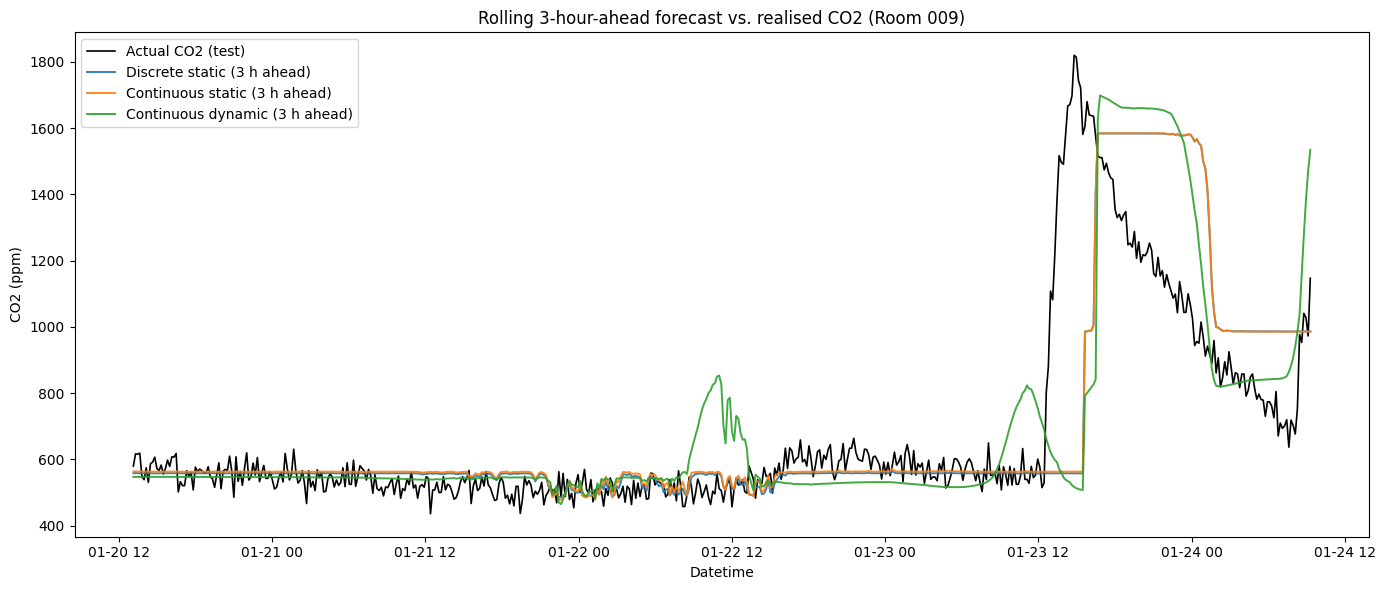

In [33]:
import matplotlib.pyplot as plt
from src.api.v4 import ForwardAlgorithm

# --- Rolling 3-hour-ahead forecast on the held-out test set -----------------
# A single long-horizon forecast from one anchor is trivially bad after a few
# steps. Instead we ask the practically relevant question at EVERY test point:
# conditioned on everything up to now, what is the CO2 WINDOW_HOURS from now?
# For each test observation we take the causal filtered state, propagate it the
# fixed horizon forward through the model's own per-step transitions, and
# compare the forecast to the CO2 actually realised that far ahead.
WINDOW_HOURS = 3
K = int(round(WINDOW_HOURS * 3600 / SECONDS))  # horizon in observation steps (~18 at 600 s)

OBS_TO_PLOT = 550
# Full-series arrays (train+test). Filtering is causal, so getting the filtered
# state at every anchor from one pass leaks nothing: the K-step-ahead forecast
# at anchor a only uses observations up to a (the covariates at a+1..a+K are
# exogenous time/weather features, not the target).
ys_full = ys
ts_full = ts
dates_full = pd.to_datetime(series_df["datetime"].values)
X_cov_std = (X_cov - cov_mean) / cov_std  # same training statistics used for fitting


def rolling_forecast(model, xs_full):
    """K-step-ahead emission forecast anchored at every test observation.

    Returns (target_dates, y_true, y_pred) aligned on the realised observation
    K steps after each test anchor.
    """
    # One causal forward pass -> filtered state after every observation.
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys_full, ts=ts_full, xs=xs_full)
    utt = out.utt.reshape(len(ys_full), -1)                                   # (T, S)
    # Per-step transition matrices Gammas[j] = P(obs j-1 -> obs j); batched once.
    Gammas = model.transition.transition_matrices(ts_full, ys_full, xs_full)  # (T, S, S)
    mu = model.emission.mu(0, ys_full, xs_full)                               # (S,) state means

    # Anchors: every test observation that still has a realised value K steps on.
    anchors = jnp.arange(TRAIN_IDX, len(ys_full) - K)
    u = utt[anchors]                                     # (A, S) filtered state at each anchor
    for m in range(1, K + 1):                            # propagate K real steps forward
        u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
    y_pred = u @ mu                                      # (A,) state-weighted emission mean
    y_true = ys_full[anchors + K]
    target_dates = dates_full[np.asarray(anchors) + K]
    return target_dates, np.asarray(y_true), np.asarray(y_pred)


models_to_plot = {
    "Discrete static":    (models_d[-1],   None),
    "Continuous static":  (models_c[-1],   None),
    "Continuous dynamic": (models_dyn[-1], X_cov_std),
}

plt.figure(figsize=(14, 6))
plotted_actual = False
for name, (model, xs_full) in models_to_plot.items():
    tdates, y_true, y_pred = rolling_forecast(model, xs_full)
    if not plotted_actual:
        plt.plot(tdates[:OBS_TO_PLOT], y_true[:OBS_TO_PLOT], color="black", lw=1.2, label="Actual CO2 (test)")
        plotted_actual = True
    plt.plot(tdates[:OBS_TO_PLOT], y_pred[:OBS_TO_PLOT], lw=1.4, alpha=0.9, label=f"{name} ({WINDOW_HOURS} h ahead)")
    print(f"{name:<20} {WINDOW_HOURS}h-ahead  RMSE={float(rmse(jnp.asarray(y_true), jnp.asarray(y_pred))):8.2f}  "
          f"R2={float(r2_score(jnp.asarray(y_true), jnp.asarray(y_pred))):7.4f}")

plt.title(f"Rolling {WINDOW_HOURS}-hour-ahead forecast vs. realised CO2 ({room_name})")
plt.xlabel("Datetime")
plt.ylabel("CO2 (ppm)")
plt.legend()
plt.tight_layout()
plt.show()
